In [49]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [50]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_codes_incl_temp_incl.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_codes_incl_temp_incl.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [51]:
# Exclude days from April through October (months 4-10) in CV_rows
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (6404926, 17)


In [52]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_filtered_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_filtered_rows: (4526168, 17)


In [53]:
CV_fog_rows = CV_filtered_rows[CV_filtered_rows["HourlyVisibility"] < 1.000]

print("CV_fog_rows:", CV_fog_rows.shape)

CV_fog_rows: (261000, 17)


In [54]:
CV_fog_rows['HourlyDewpointDepression'] = (
    CV_fog_rows['HourlyDryBulbTemperature'] - CV_fog_rows['HourlyDewPointTemperature']
)

CV_fog_rows[['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlyDewpointDepression']].head()

,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyDewpointDepression
6,11.9,11.9,0.0
7,11.9,11.9,0.0
8,11.9,11.9,0.0
9,11.9,11.9,0.0
10,13.5,12.4,1.1


In [55]:
CV_rows['HourlyDewpointDepression'] = (
    CV_rows['HourlyDryBulbTemperature'] - CV_rows['HourlyDewPointTemperature']
)

CV_rows[['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlyDewpointDepression']].head()

,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyDewpointDepression
0,13.0,11.9,1.1
1,12.4,10.7,1.7
2,12.4,11.3,1.1
3,12.4,11.3,1.1
4,13.0,11.9,1.1


C:\Users\Work Account\AppData\Local\Temp\ipykernel_15676\2200550987.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


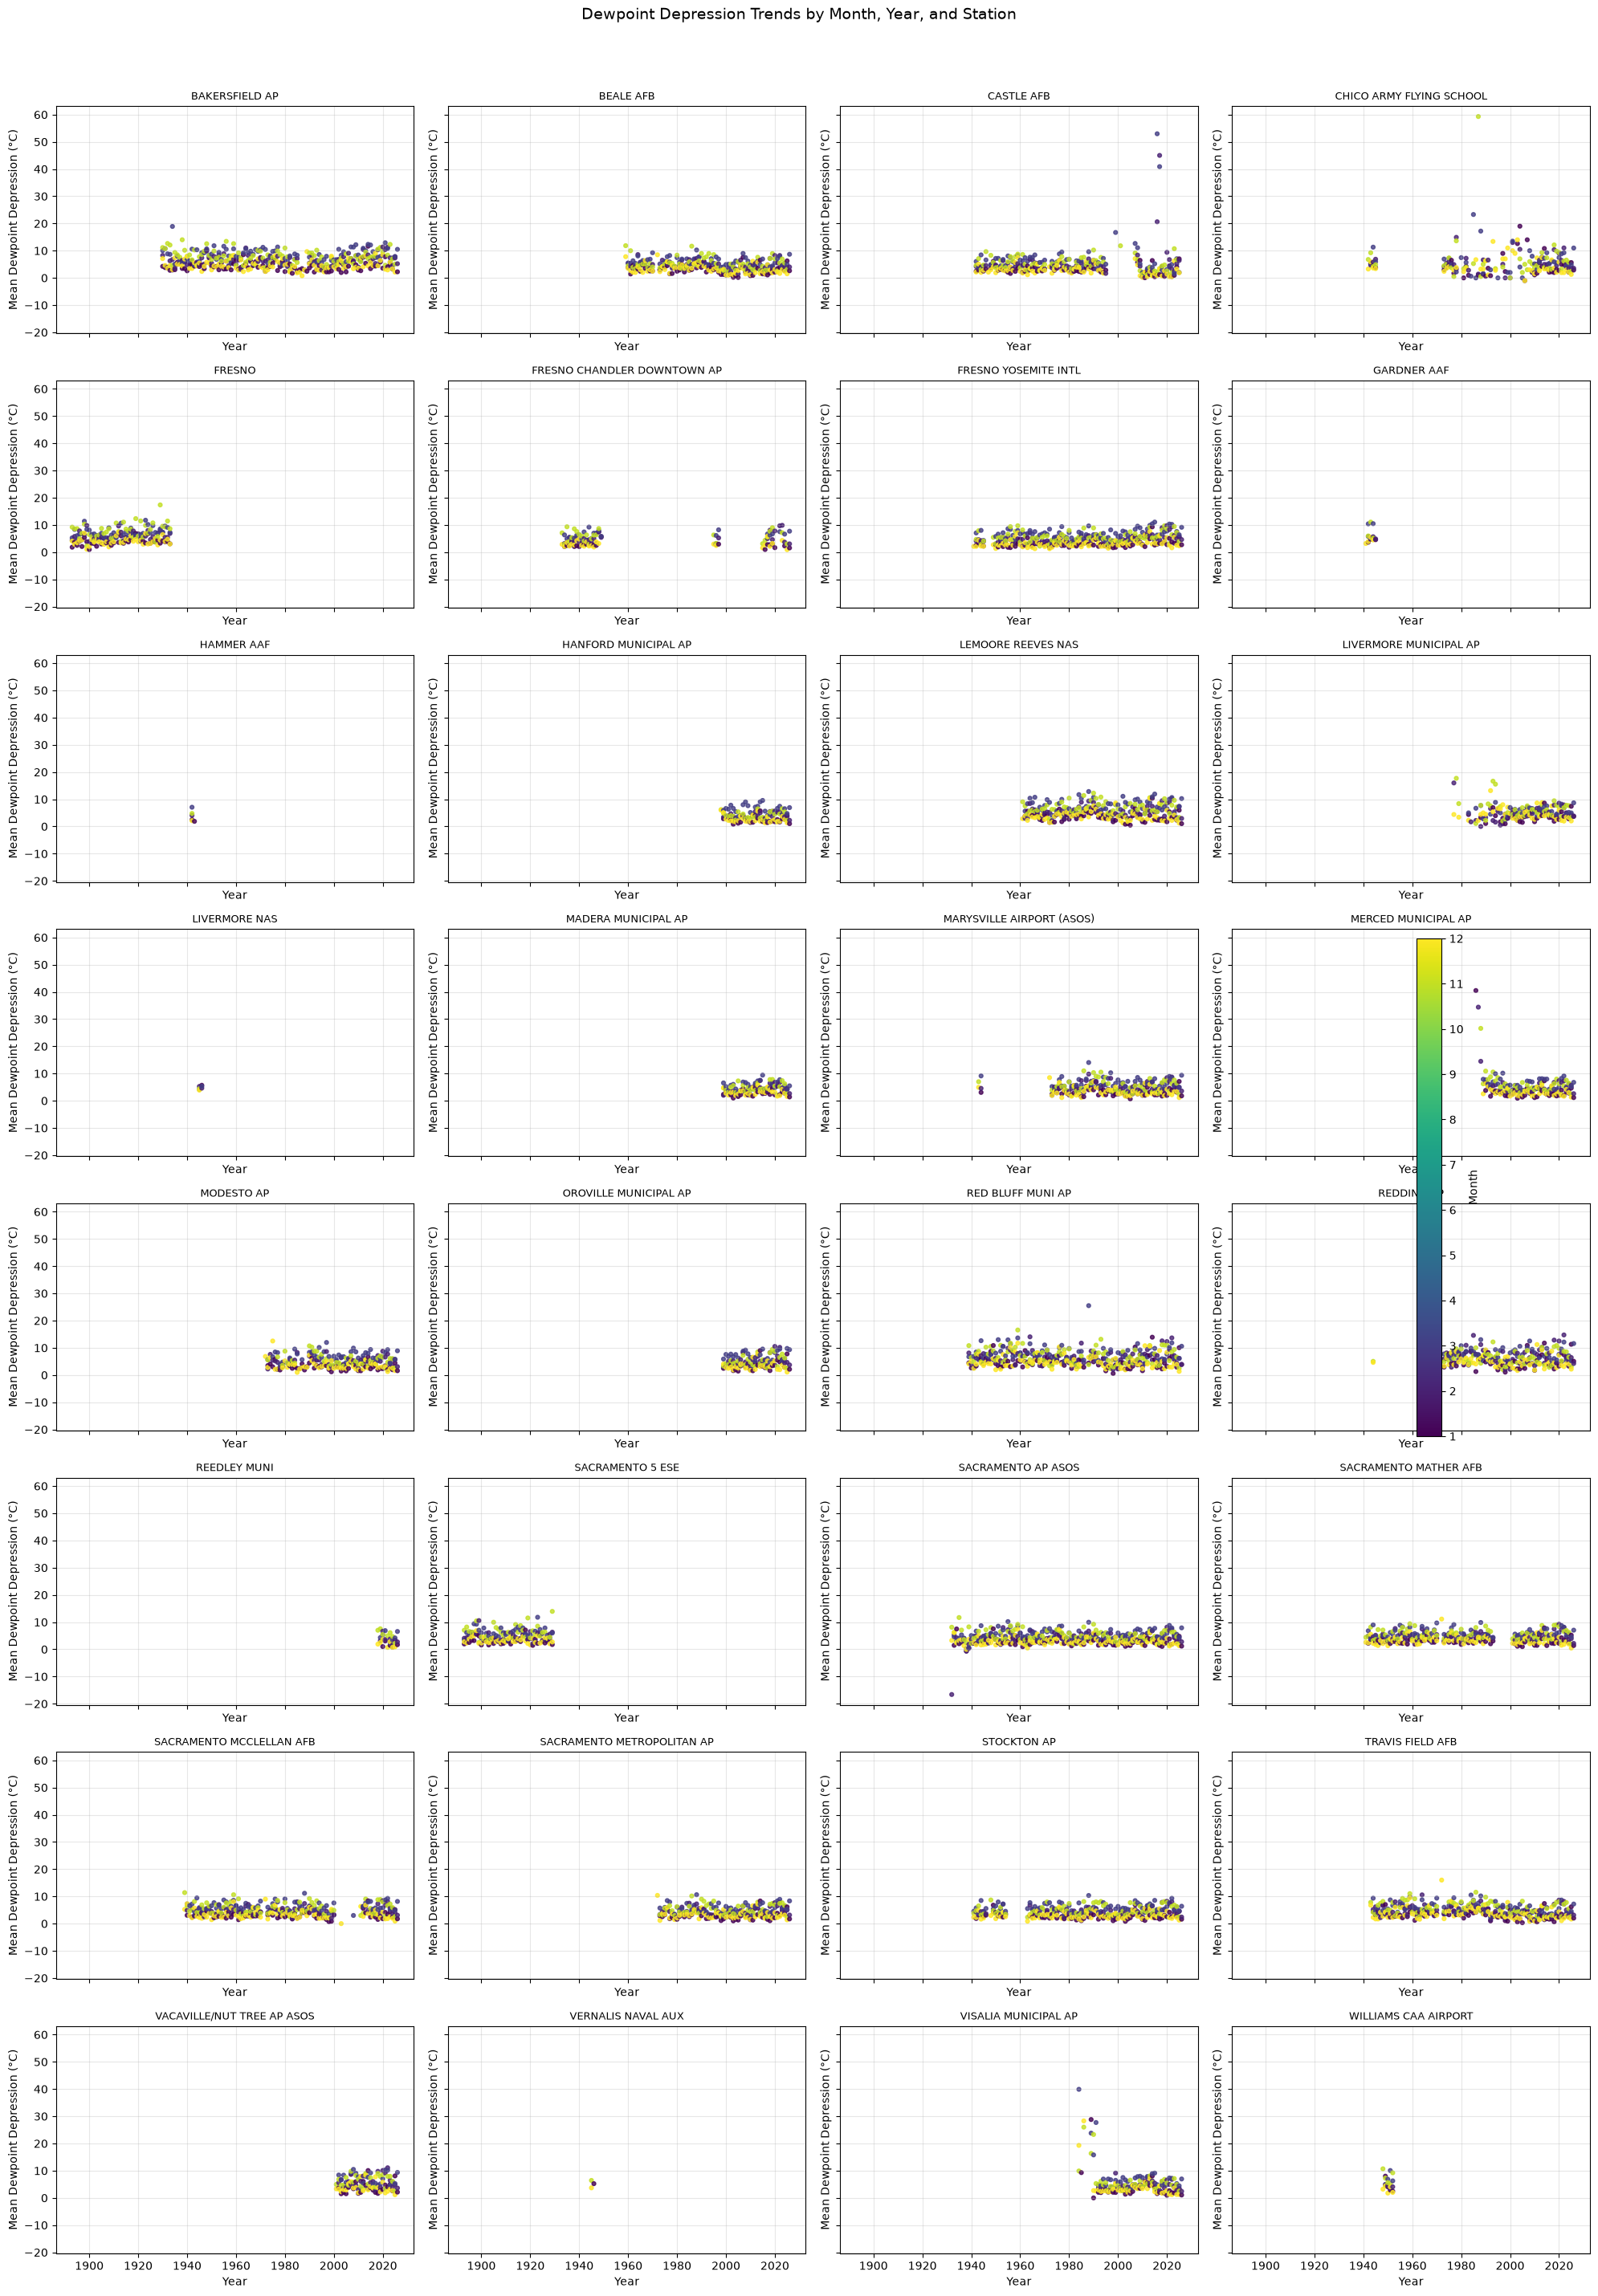

In [56]:
# Monthly mean dewpoint depression by station/year/month
# need to only calculate dewpoint depression if the rows have both temperature and dewpoint values
# filter out rows without both temperature and dewpoint values
CV_rows = CV_rows.dropna(subset=["HourlyDryBulbTemperature", "HourlyDewPointTemperature"])

monthly_station = (
    CV_rows.groupby(["STATION", "year", "month"], as_index=False)["HourlyDewpointDepression"]
    .mean()
    .sort_values(["STATION", "year", "month"])
)

stations = sorted(monthly_station["STATION"].dropna().unique())
n_stations = len(stations)

ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

for i, station in enumerate(stations):
    ax = axes[i]
    sdata = monthly_station[monthly_station["STATION"] == station]

    ax.scatter(
        sdata["year"],
        sdata["HourlyDewpointDepression"],
        c=sdata["month"],
        cmap="viridis",
        vmin=1,
        vmax=12,
        s=12,
        alpha=0.8
    )
    ax.set_title(station, fontsize=9)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Shared colorbar for month
smb = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=1, vmax=12))
smb.set_array([])
cbar = fig.colorbar(smb, ax=axes.tolist(), fraction=0.02, pad=0.01)
cbar.set_label("Month")
cbar.set_ticks(range(1, 13))

fig.suptitle("Dewpoint Depression Trends by Month, Year, and Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_15676\343269217.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


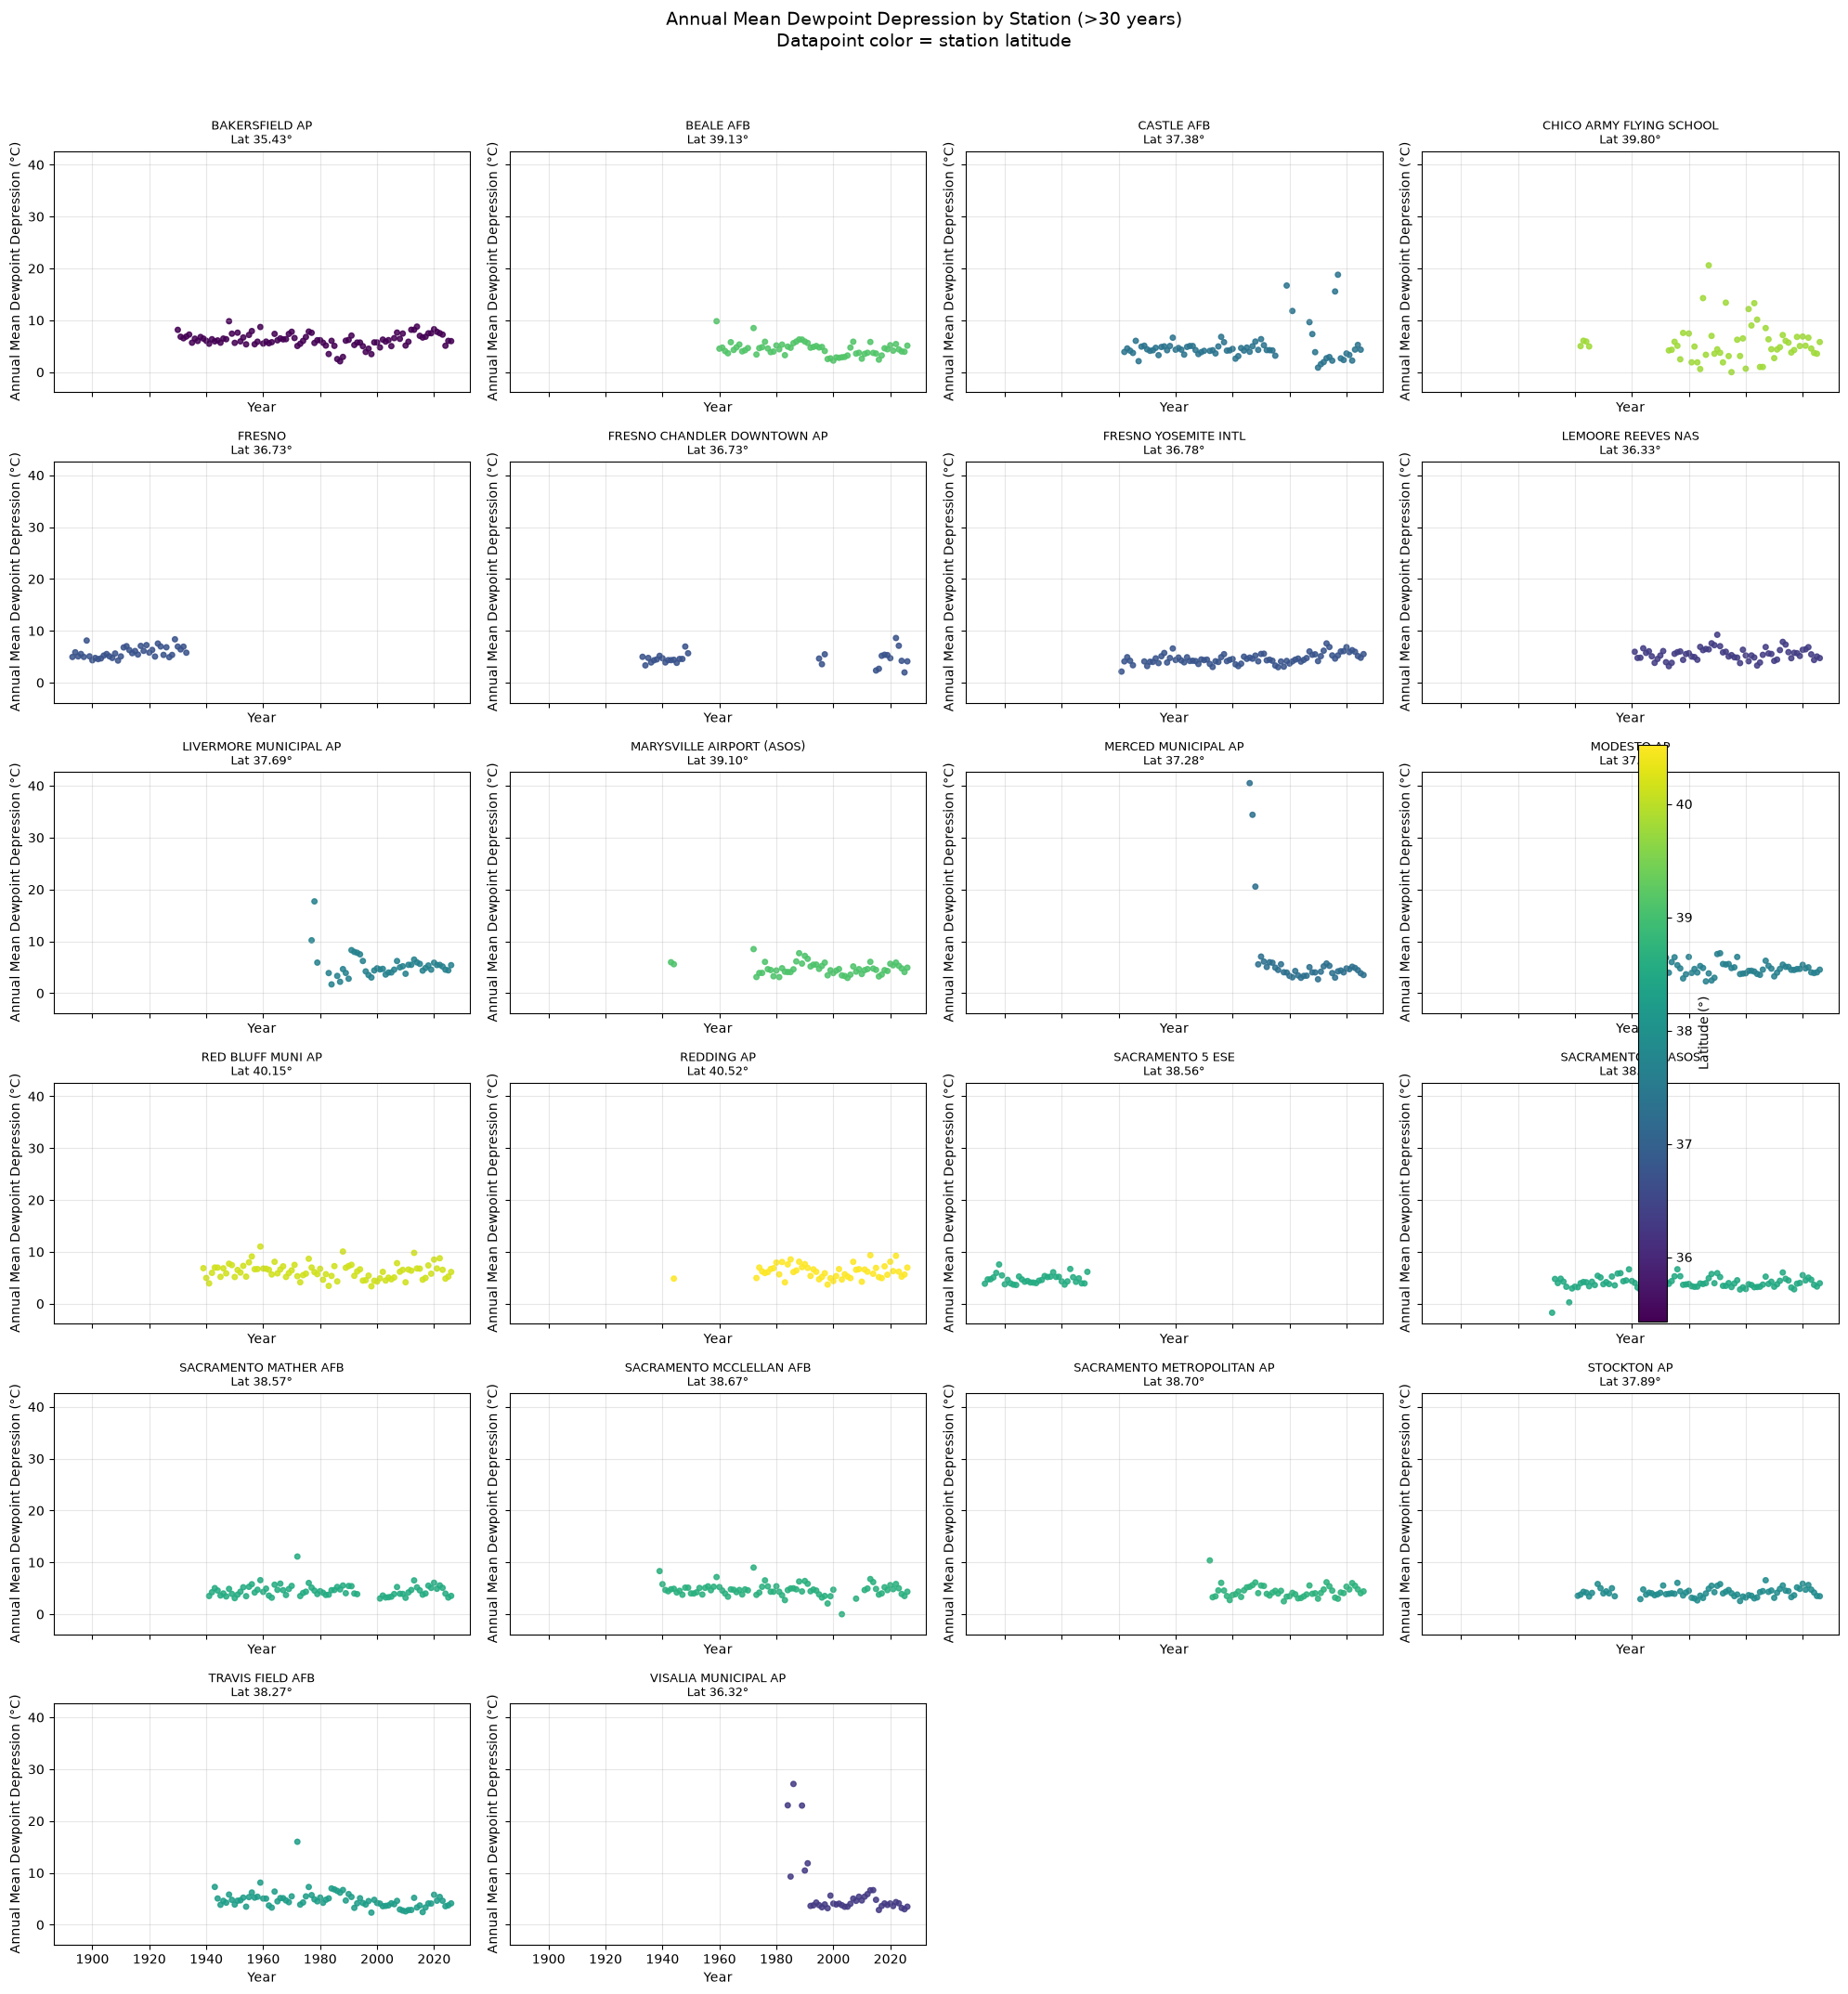

In [57]:
# Annual mean dewpoint depression by station/year
annual_station = (
    monthly_station.groupby(["STATION", "year"], as_index=False)["HourlyDewpointDepression"]
    .mean()
)

# Keep stations with >30 unique years of annual data
year_counts = annual_station.groupby("STATION")["year"].nunique()
eligible_stations_30 = year_counts[year_counts > 30].index

annual_station_30 = annual_station[annual_station["STATION"].isin(eligible_stations_30)].copy()

# Station latitude lookup
station_lat = (
    CV_rows[["STATION", "LATITUDE"]]
    .dropna()
    .groupby("STATION", as_index=True)["LATITUDE"]
    .median()
)

annual_station_30["LATITUDE"] = annual_station_30["STATION"].map(station_lat)

# Plot
stations_30 = sorted(annual_station_30["STATION"].dropna().unique())
n_stations_30 = len(stations_30)

if n_stations_30 == 0:
    print("No stations found with more than 30 years of data.")
else:
    ncols = 4
    nrows = int(np.ceil(n_stations_30 / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 3.5 * nrows),
        sharex=True,
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    lat_min = annual_station_30["LATITUDE"].min()
    lat_max = annual_station_30["LATITUDE"].max()
    norm = plt.Normalize(vmin=lat_min, vmax=lat_max)
    cmap = "viridis"

    for idx, station_name in enumerate(stations_30):
        ax = axes[idx]
        g = annual_station_30[annual_station_30["STATION"] == station_name].sort_values("year")
        lat_val = g["LATITUDE"].iloc[0]

        ax.scatter(
            g["year"],
            g["HourlyDewpointDepression"],
            c=np.full(len(g), lat_val),
            cmap=cmap,
            norm=norm,
            s=16,
            alpha=0.85
        )
        ax.set_title(f"{station_name}\nLat {lat_val:.2f}°", fontsize=9)
        ax.set_xlabel("Year")
        ax.set_ylabel("Annual Mean Dewpoint Depression (°C)")
        ax.grid(alpha=0.3)

    for idx in range(n_stations_30, len(axes)):
        axes[idx].axis("off")

    sma = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sma.set_array([])
    cbar = fig.colorbar(sma, ax=axes.tolist(), fraction=0.02, pad=0.01)
    cbar.set_label("Latitude (°)")

    fig.suptitle(
        "Annual Mean Dewpoint Depression by Station (>30 years)\nDatapoint color = station latitude",
        y=1.02,
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

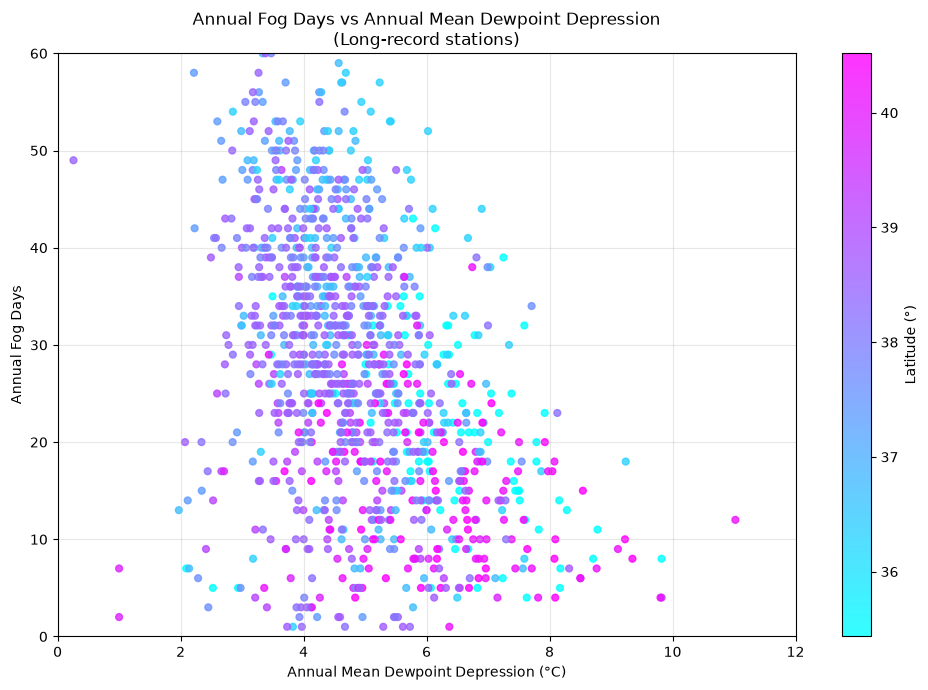

In [60]:
# Annual fog days (unique dates with fog) by station/year
fog_days_annual = (
    CV_fog_rows.assign(fog_date=pd.to_datetime(CV_fog_rows["DATE"], errors="coerce").dt.date)
    .dropna(subset=["fog_date"])
    .groupby(["STATION", "year"], as_index=False)["fog_date"]
    .nunique()
    .rename(columns={"fog_date": "annual_fog_days"})
)

# Keep only stations with long records (as defined above)
long_record_stations = set(eligible_stations_30)
fog_days_annual = fog_days_annual[fog_days_annual["STATION"].isin(long_record_stations)]

# Merge with annual mean dewpoint depression and latitude
plot_df = fog_days_annual.merge(
    annual_station_30[["STATION", "year", "HourlyDewpointDepression", "LATITUDE"]],
    on=["STATION", "year"],
    how="inner"
)

# Scatterplot: annual fog days vs annual mean dewpoint depression, colored by latitude
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    plot_df["HourlyDewpointDepression"],
    plot_df["annual_fog_days"],
    c=plot_df["LATITUDE"],
    cmap="cool",  # make colorbar blue to red for north to south
    s=24,
    alpha=0.8
)

plt.xlim(0,12)
plt.ylim(0,60)


ax.set_title("Annual Fog Days vs Annual Mean Dewpoint Depression\n(Long-record stations)")
ax.set_xlabel("Annual Mean Dewpoint Depression (°C)")
ax.set_ylabel("Annual Fog Days")
ax.grid(alpha=0.3)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Latitude (°)")

plt.tight_layout()
plt.show()

Rows before outlier removal: 1131
Rows after outlier removal: 1105
                            OLS Regression Results                            
Dep. Variable:        annual_fog_days   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     162.9
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           1.03e-62
Time:                        12:09:04   Log-Likelihood:                -4287.8
No. Observations:                1105   AIC:                             8582.
Df Residuals:                    1102   BIC:                             8597.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

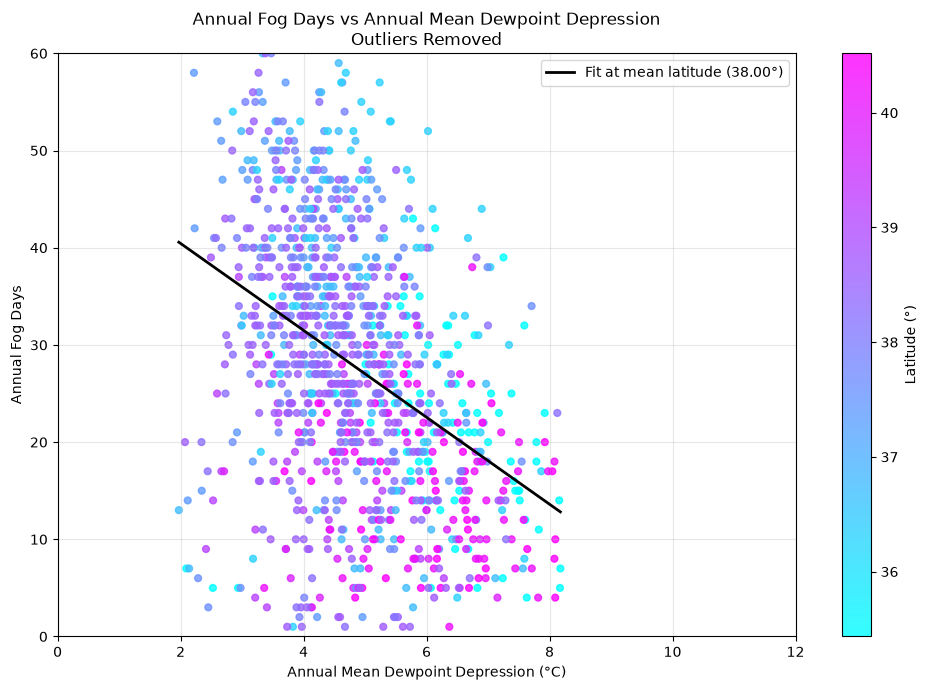

In [62]:
# Remove outliers from plot_df using the IQR rule and fit a linear model

clean_df = plot_df[["HourlyDewpointDepression", "annual_fog_days", "LATITUDE"]].dropna().copy()

for col in ["HourlyDewpointDepression", "annual_fog_days"]:
    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    clean_df = clean_df[(clean_df[col] >= lower) & (clean_df[col] <= upper)]

print("Rows before outlier removal:", len(plot_df))
print("Rows after outlier removal:", len(clean_df))

X_clean = sm.add_constant(clean_df[["HourlyDewpointDepression", "LATITUDE"]])
y_clean = clean_df["annual_fog_days"]

clean_model = sm.OLS(y_clean, X_clean).fit()
print(clean_model.summary())

lat_ref_clean = clean_df["LATITUDE"].mean()
dd_range_clean = np.linspace(
    clean_df["HourlyDewpointDepression"].min(),
    clean_df["HourlyDewpointDepression"].max(),
    100
)

pred_clean_df = pd.DataFrame({
    "const": 1.0,
    "HourlyDewpointDepression": dd_range_clean,
    "LATITUDE": lat_ref_clean
})
pred_clean_df["predicted_fog_days"] = clean_model.predict(pred_clean_df)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    clean_df["HourlyDewpointDepression"],
    clean_df["annual_fog_days"],
    c=clean_df["LATITUDE"],
    cmap="cool",
    s=24,
    alpha=0.8
)

ax.plot(
    pred_clean_df["HourlyDewpointDepression"],
    pred_clean_df["predicted_fog_days"],
    color="black",
    linewidth=2,
    label=f"Fit at mean latitude ({lat_ref_clean:.2f}°)"
)

plt.xlim(0,12)
plt.ylim(0,60)

ax.set_title("Annual Fog Days vs Annual Mean Dewpoint Depression\nOutliers Removed")
ax.set_xlabel("Annual Mean Dewpoint Depression (°C)")
ax.set_ylabel("Annual Fog Days")
ax.grid(alpha=0.3)
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Latitude (°)")

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:        annual_fog_days   R-squared:                       0.205
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                     145.8
Date:                Wed, 05 Aug 2026   Prob (F-statistic):           4.76e-57
Time:                        11:36:18   Log-Likelihood:                -4434.2
No. Observations:                1131   AIC:                             8874.
Df Residuals:                    1128   BIC:                             8889.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

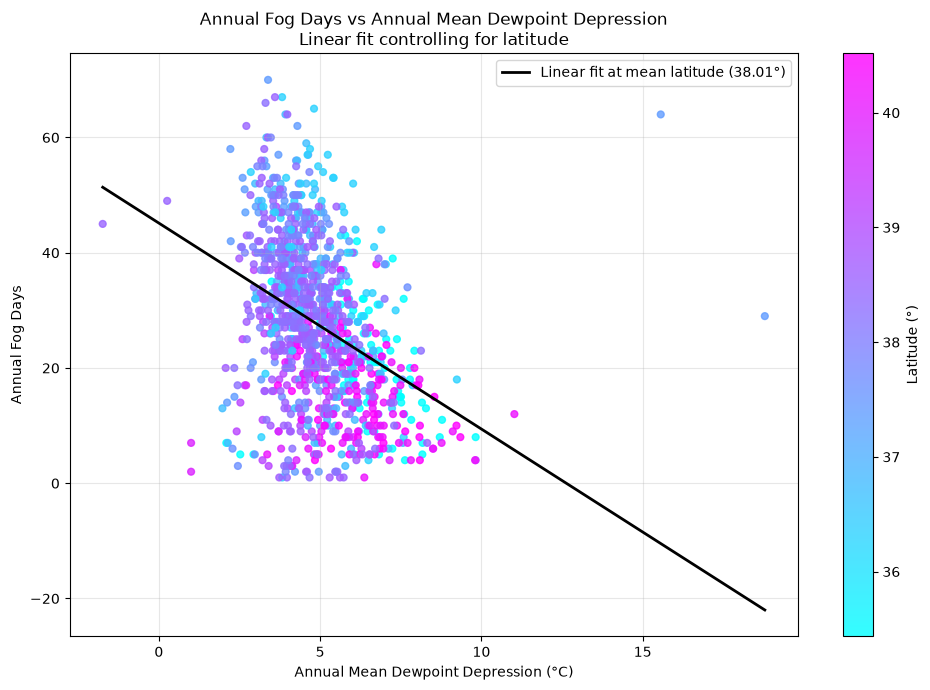

In [59]:
# Multiple linear regression: annual fog days as a function of
# annual mean dewpoint depression and latitude
X_fit = sm.add_constant(plot_df[["HourlyDewpointDepression", "LATITUDE"]])
y_fit = plot_df["annual_fog_days"]

fog_dd_lat_model = sm.OLS(y_fit, X_fit).fit()
print(fog_dd_lat_model.summary())

# Predicted relationship at mean latitude
lat_ref_fit = plot_df["LATITUDE"].mean()
dd_range_fit = np.linspace(
    plot_df["HourlyDewpointDepression"].min(),
    plot_df["HourlyDewpointDepression"].max(),
    100
)

pred_fit_df = pd.DataFrame({
    "const": 1.0,
    "HourlyDewpointDepression": dd_range_fit,
    "LATITUDE": lat_ref_fit
})
pred_fit_df["predicted_fog_days"] = fog_dd_lat_model.predict(pred_fit_df)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    plot_df["HourlyDewpointDepression"],
    plot_df["annual_fog_days"],
    c=plot_df["LATITUDE"],
    cmap="cool",
    s=24,
    alpha=0.8
)

ax.plot(
    pred_fit_df["HourlyDewpointDepression"],
    pred_fit_df["predicted_fog_days"],
    color="black",
    linewidth=2,
    label=f"Linear fit at mean latitude ({lat_ref_fit:.2f}°)"
)

ax.set_title("Annual Fog Days vs Annual Mean Dewpoint Depression\nLinear fit controlling for latitude")
ax.set_xlabel("Annual Mean Dewpoint Depression (°C)")
ax.set_ylabel("Annual Fog Days")
ax.grid(alpha=0.3)
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Latitude (°)")

plt.tight_layout()
plt.show()

In [10]:
outliers = CV_rows[(CV_rows["HourlyDewpointDepression"] > 40) | (CV_rows["HourlyDewpointDepression"] < 0)]

print(outliers)

           STATION_ID  LATITUDE  LONGITUDE                 DATE  \
16939     USM00074917   35.1170  -119.3000  1943-11-07 10:00:00   
16940     USM00074917   35.1170  -119.3000  1943-11-07 11:00:00   
16941     USM00074917   35.1170  -119.3000  1943-11-07 12:00:00   
16943     USM00074917   35.1170  -119.3000  1943-11-07 14:00:00   
16946     USM00074917   35.1170  -119.3000  1943-11-07 17:00:00   
...               ...       ...        ...                  ...   
10776303  USW00024257   40.5175  -122.2986  2022-10-19 15:53:00   
10799934  USW00024257   40.5175  -122.2986  2024-10-05 11:53:00   
10799935  USW00024257   40.5175  -122.2986  2024-10-05 12:53:00   
10799936  USW00024257   40.5175  -122.2986  2024-10-05 13:00:00   
10803163  USW00024257   40.5175  -122.2986  2024-12-26 12:53:00   

          HourlyDewPointTemperature  HourlyDryBulbTemperature  \
16939                         -19.2                      22.4   
16940                         -17.6                      23.5   


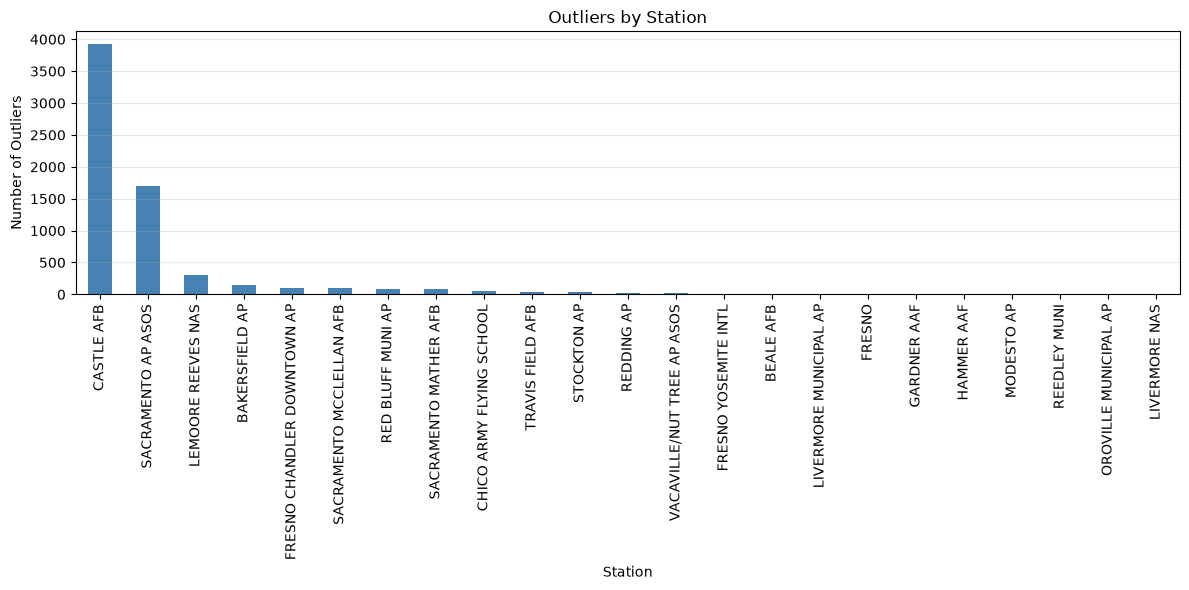

In [11]:
# Count outliers by station and plot
outlier_counts = outliers["STATION"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
outlier_counts.plot(kind="bar", ax=ax, color="steelblue")

ax.set_title("Outliers by Station")
ax.set_xlabel("Station")
ax.set_ylabel("Number of Outliers")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

                        STATION  n_years  start_year  end_year  \
26         WILLIAMS CAA AIRPORT        4        1949      1952   
17                 REEDLEY MUNI        4        2018      2025   
1                     BEALE AFB       52        1959      2025   
2                    CASTLE AFB       54        1942      2025   
25         VISALIA MUNICIPAL AP       21        2005      2025   
13                   MODESTO AP       44        1973      2025   
0                BAKERSFIELD AP       92        1930      2025   
18           SACRAMENTO AP ASOS       89        1933      2025   
23             TRAVIS FIELD AFB       68        1943      2025   
19        SACRAMENTO MATHER AFB       64        1941      2025   
22                  STOCKTON AP       63        1941      2025   
4   FRESNO CHANDLER DOWNTOWN AP       20        1933      2025   
8            LEMOORE REEVES NAS       57        1961      2025   
7          HANFORD MUNICIPAL AP       21        2005      2025   
20     SAC

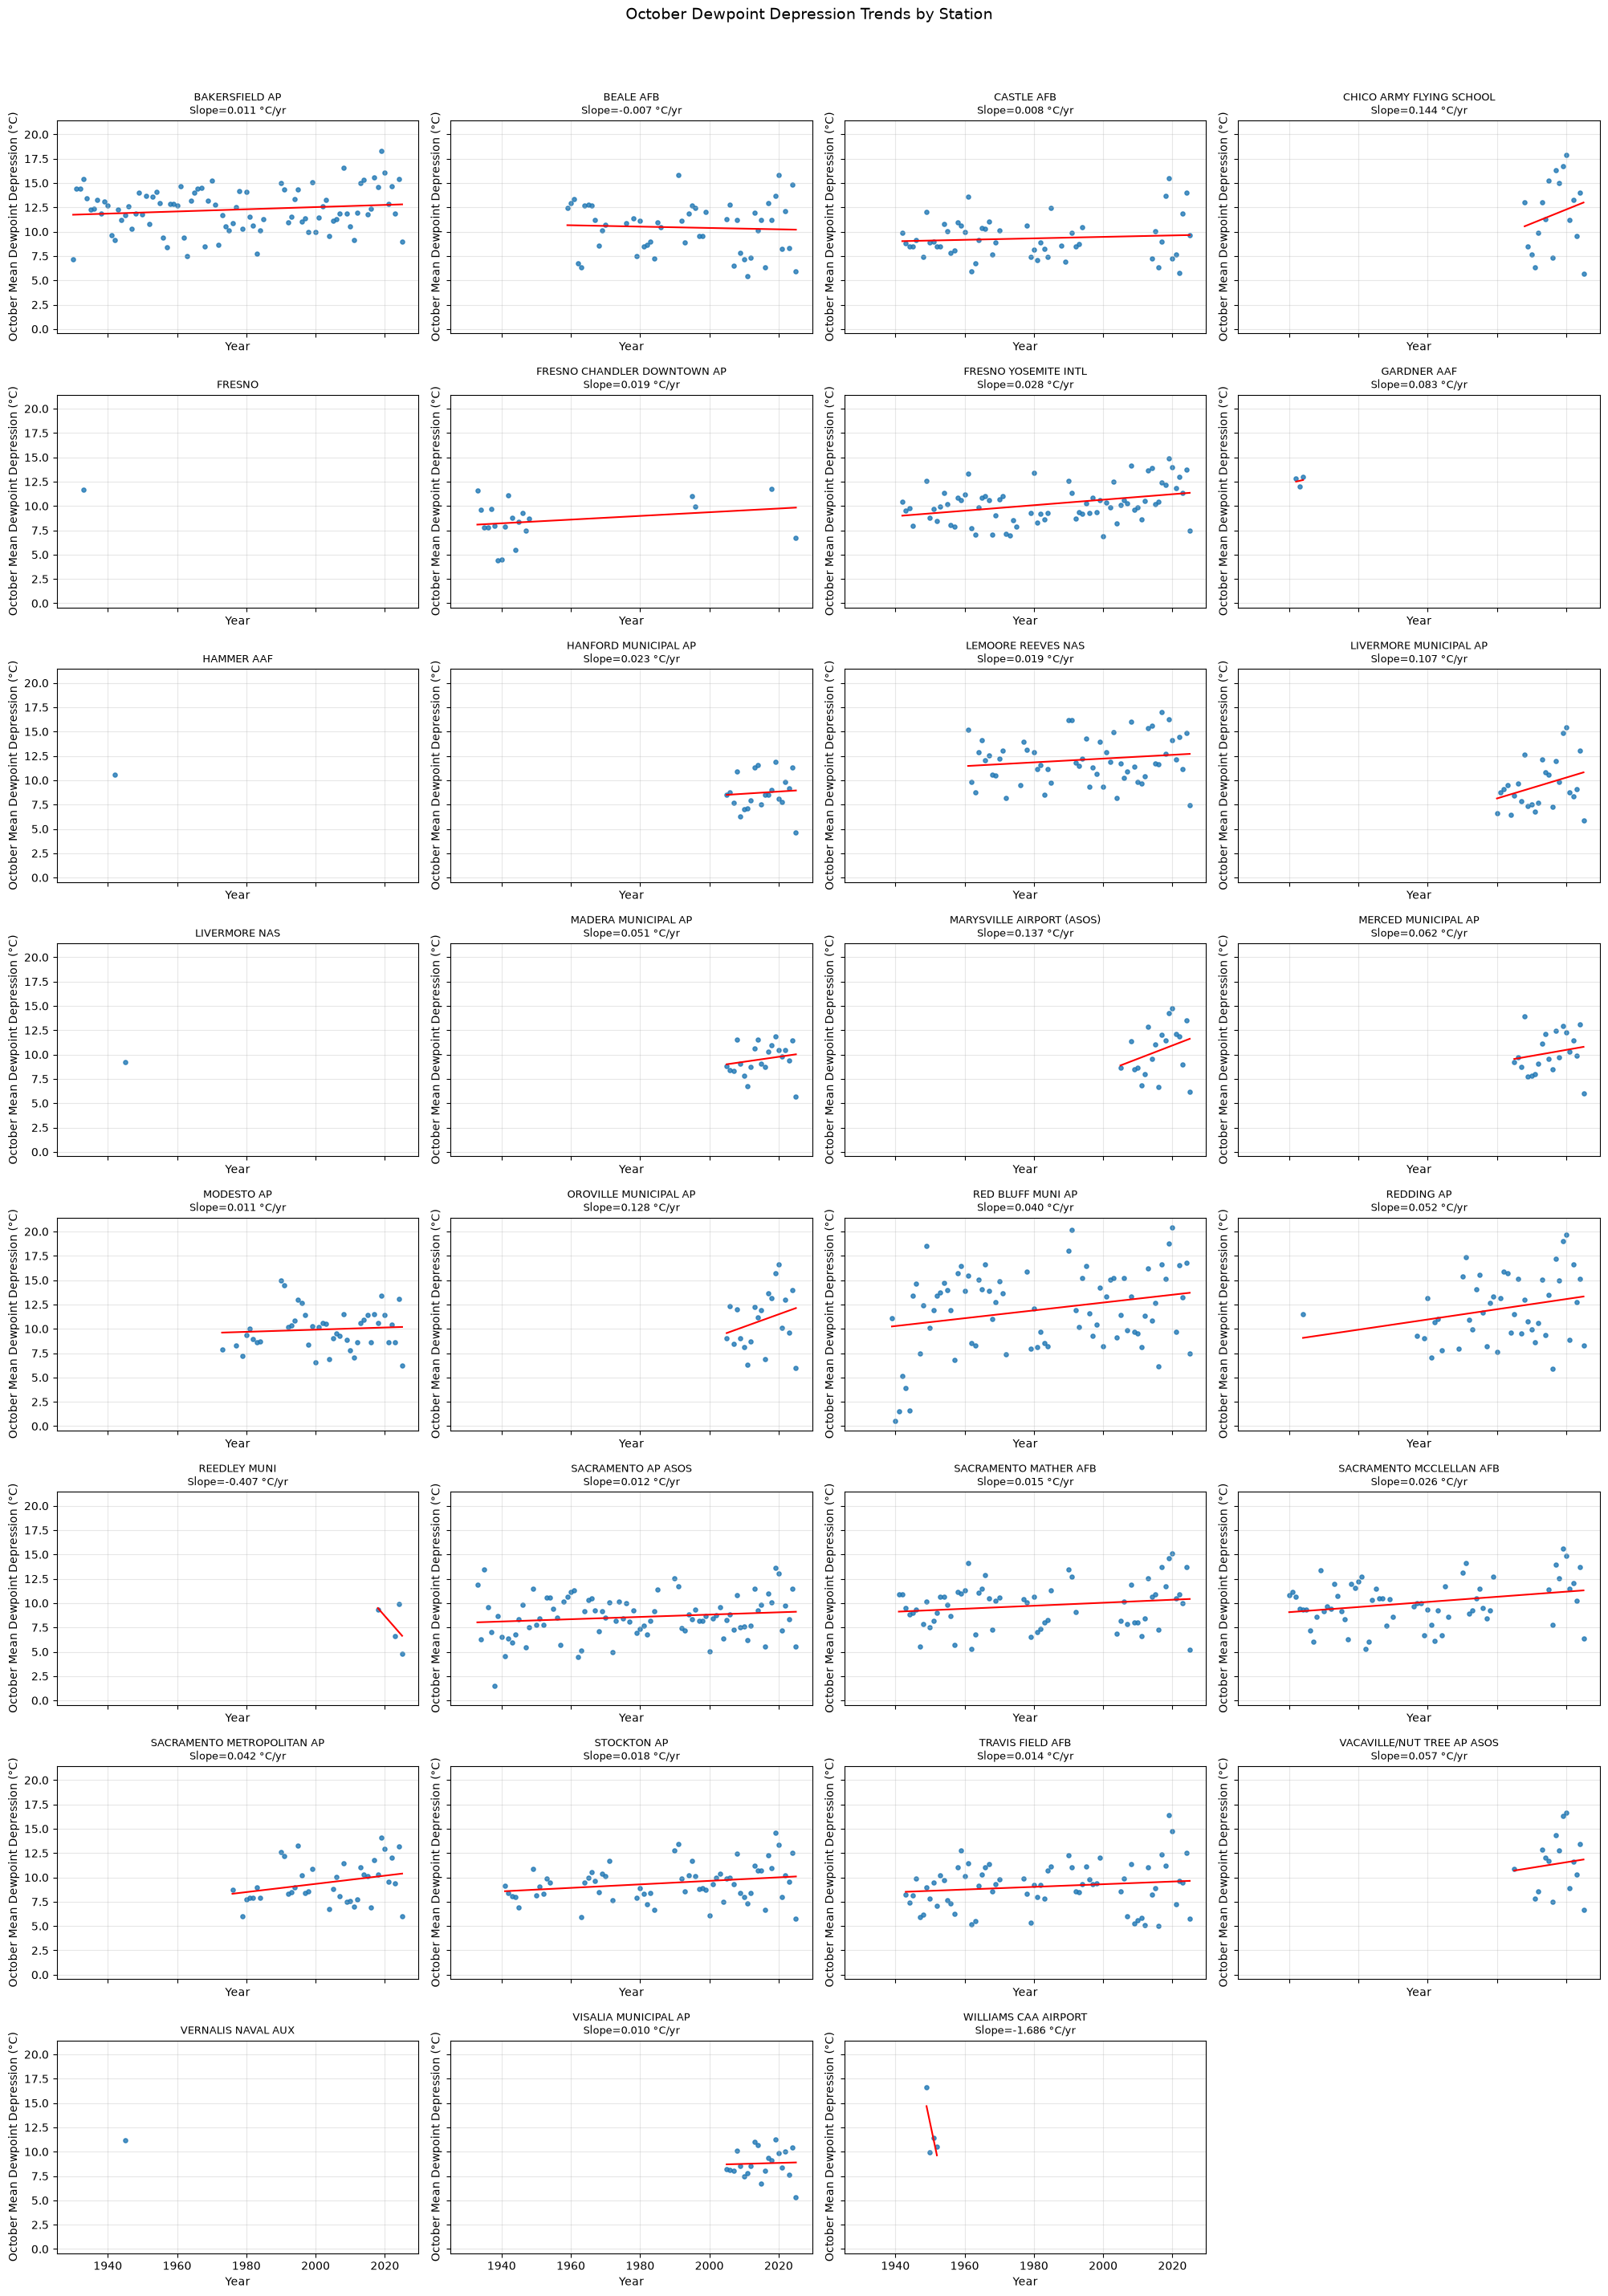

In [6]:
# October mean dewpoint depression by station and year
october_station = (
    monthly_station[monthly_station["month"] == 10]
    .dropna(subset=["HourlyDewpointDepression"])
    .copy()
)

# Linear trend for October dewpoint depression at each station
trend_rows = []
for station_name, g in october_station.groupby("STATION"):
    g = g.sort_values("year")
    if g["year"].nunique() < 2:
        continue

    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    trend_rows.append({
        "STATION": station_name,
        "n_years": g["year"].nunique(),
        "start_year": g["year"].min(),
        "end_year": g["year"].max(),
        "slope_per_year": fit.slope,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue
    })

october_trends = pd.DataFrame(trend_rows).sort_values("slope_per_year")
print(october_trends)

# Plot October trends for each station
october_stations = sorted(october_station["STATION"].unique())
n_oct_stations = len(october_stations)
ncols = 4
nrows = int(np.ceil(n_oct_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

for idx, station_name in enumerate(october_stations):
    ax = axes[idx]
    g = october_station[october_station["STATION"] == station_name].sort_values("year")

    ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

    if g["year"].nunique() >= 2:
        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        y = fit.intercept + fit.slope * x
        ax.plot(x, y, color="red", linewidth=1.5)
        ax.set_title(f"{station_name}\nSlope={fit.slope:.3f} °C/yr", fontsize=9)
    else:
        ax.set_title(station_name, fontsize=9)

    ax.set_xlabel("Year")
    ax.set_ylabel("October Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for idx in range(n_oct_stations, len(axes)):
    axes[idx].axis("off")

fig.suptitle("October Dewpoint Depression Trends by Station", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

                        STATION  n_years  start_year  end_year  \
26         WILLIAMS CAA AIRPORT        4        1949      1952   
17                 REEDLEY MUNI        4        2018      2025   
1                     BEALE AFB       52        1959      2025   
2                    CASTLE AFB       54        1942      2025   
25         VISALIA MUNICIPAL AP       21        2005      2025   
13                   MODESTO AP       44        1973      2025   
0                BAKERSFIELD AP       92        1930      2025   
18           SACRAMENTO AP ASOS       89        1933      2025   
23             TRAVIS FIELD AFB       68        1943      2025   
19        SACRAMENTO MATHER AFB       64        1941      2025   
22                  STOCKTON AP       63        1941      2025   
4   FRESNO CHANDLER DOWNTOWN AP       20        1933      2025   
8            LEMOORE REEVES NAS       57        1961      2025   
7          HANFORD MUNICIPAL AP       21        2005      2025   
20     SAC

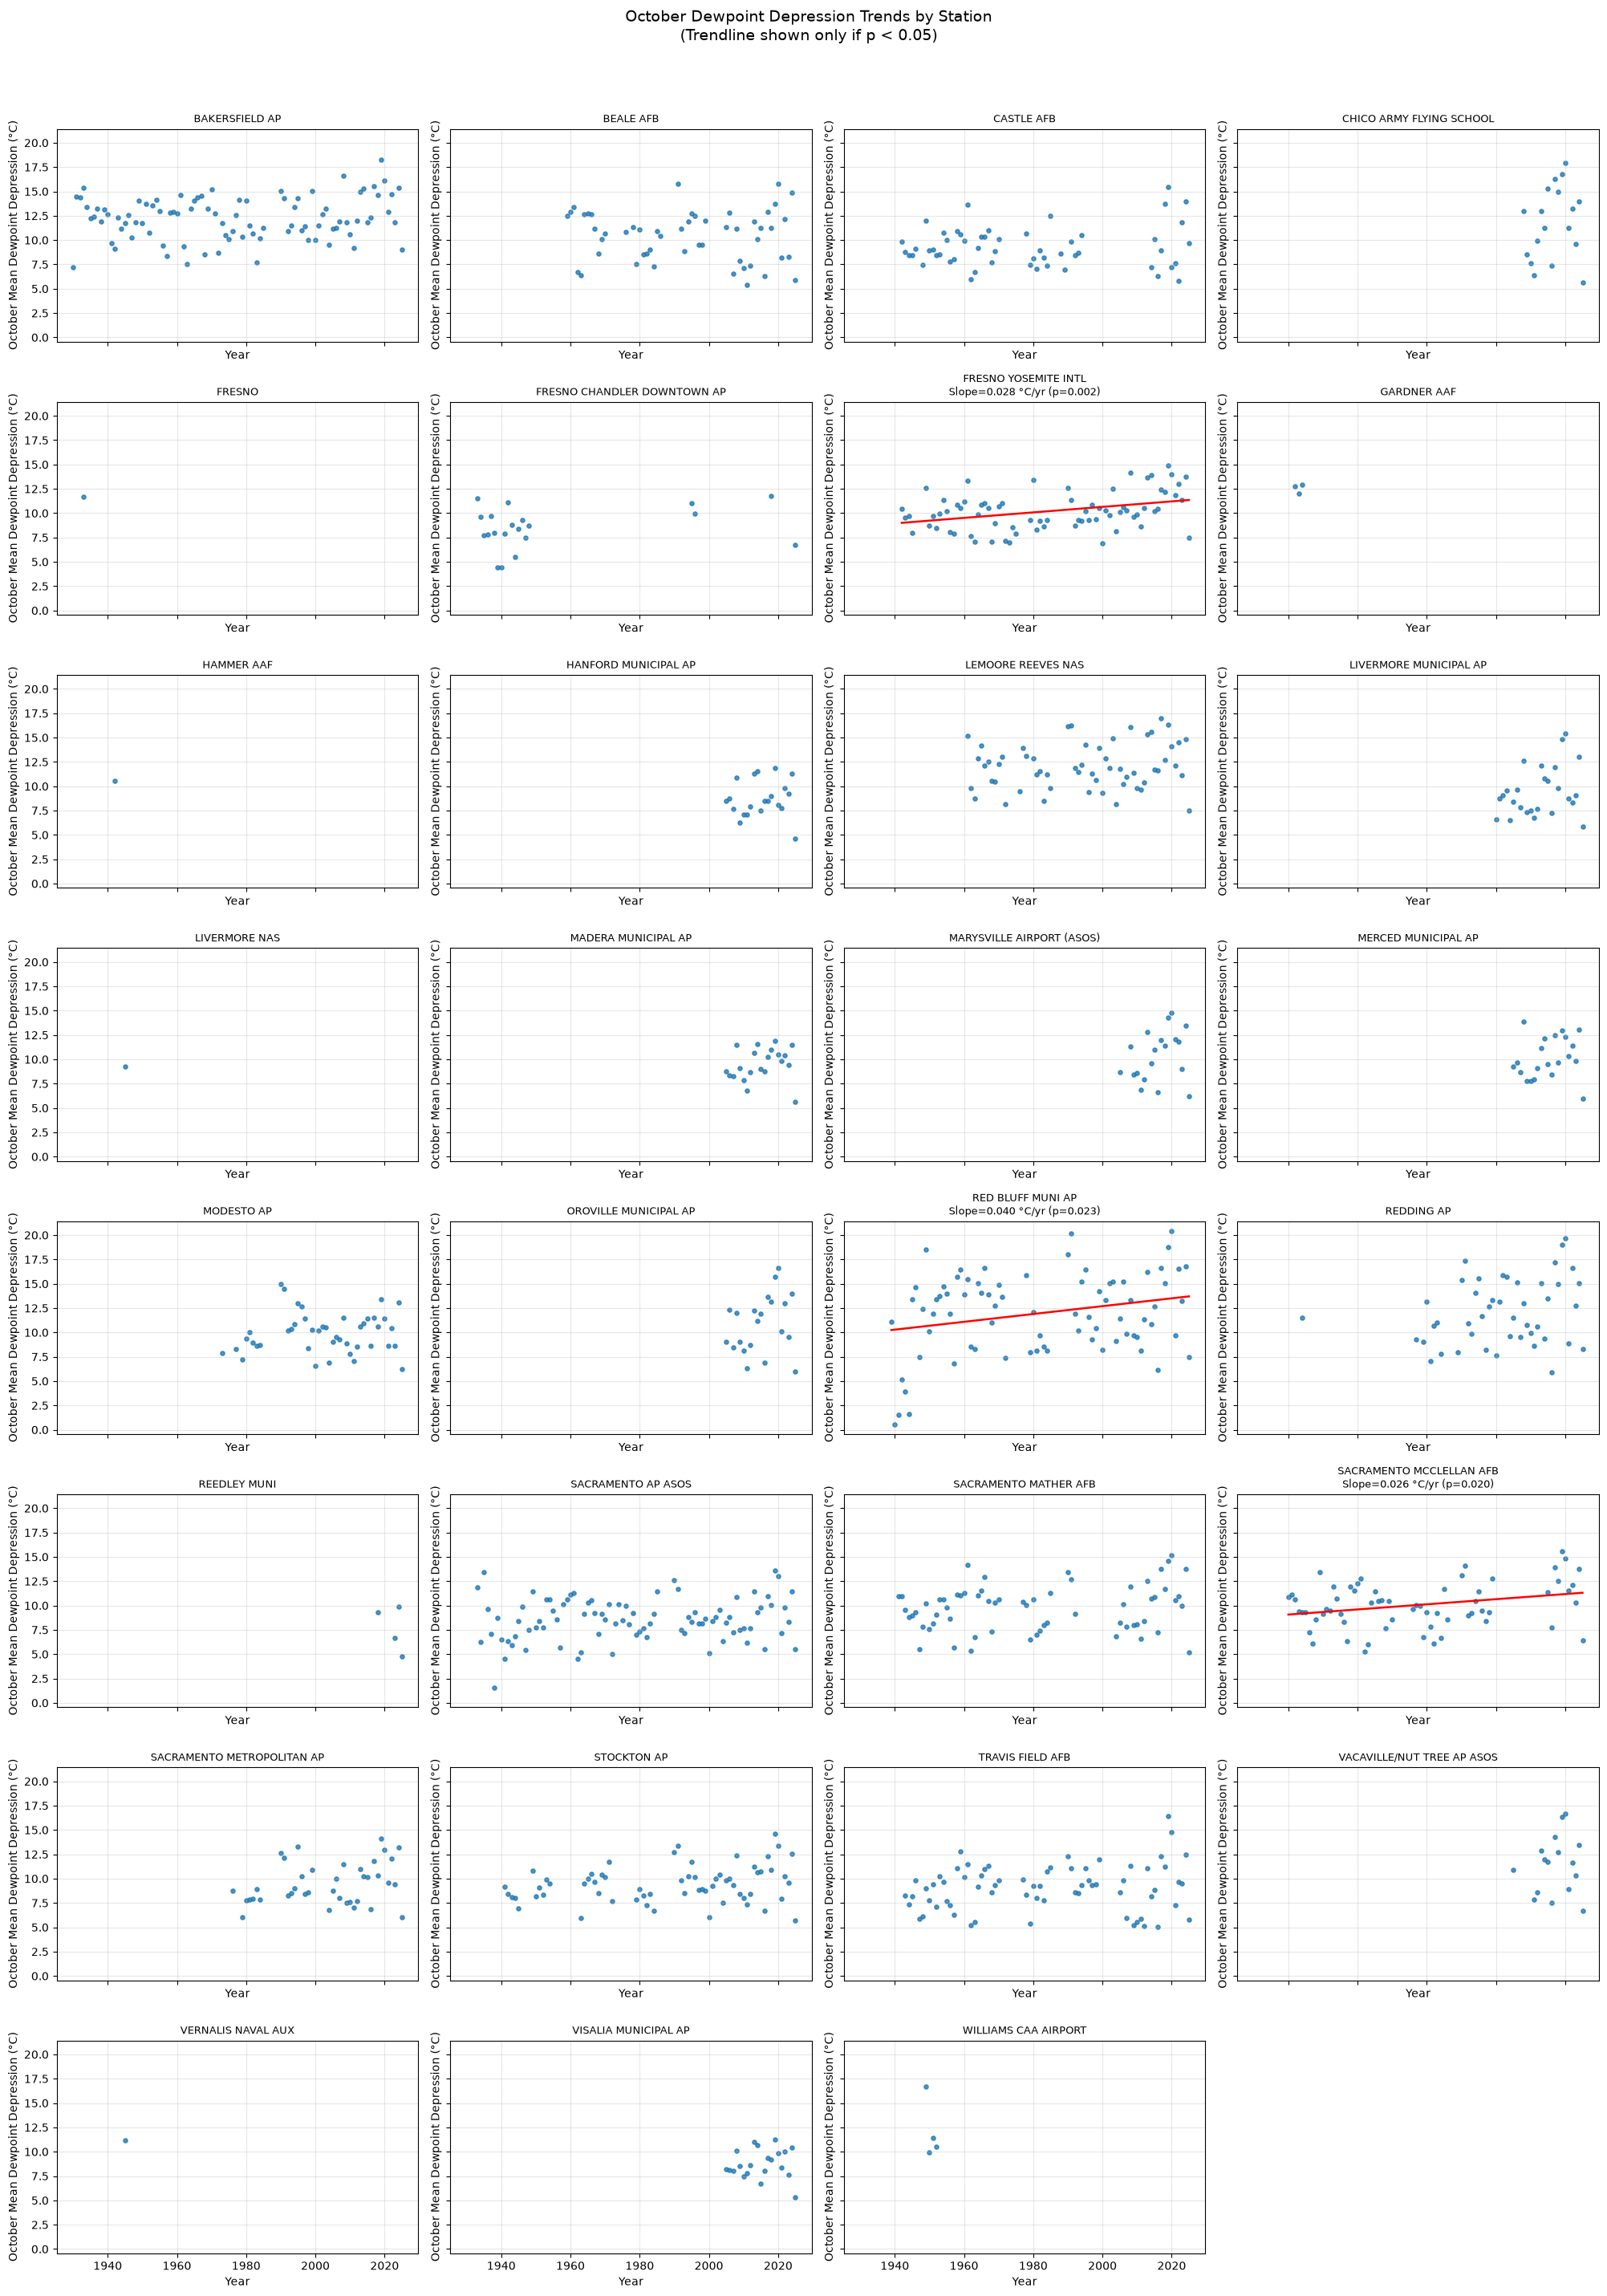

In [7]:
# October mean dewpoint depression by station/year
october_station = (
    monthly_station[monthly_station["month"] == 10]
    .dropna(subset=["HourlyDewpointDepression"])
    .copy()
)

# Trend analysis per station
alpha = 0.05
trend_rows = []

for station_name, g in october_station.groupby("STATION"):
    g = g.sort_values("year")
    if g["year"].nunique() < 2:
        continue

    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    trend_rows.append({
        "STATION": station_name,
        "n_years": g["year"].nunique(),
        "start_year": g["year"].min(),
        "end_year": g["year"].max(),
        "slope_per_year": fit.slope,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue,
        "significant": fit.pvalue < alpha
    })

october_trends = pd.DataFrame(trend_rows).sort_values("slope_per_year")
print(october_trends)

print("\nSignificant trends (p < 0.05):")
print(october_trends[october_trends["significant"]])

# Scatter plots: only significant stations get trendlines
october_stations = sorted(october_station["STATION"].unique())
n_oct_stations = len(october_stations)
ncols = 4
nrows = int(np.ceil(n_oct_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

sig_lookup = october_trends.set_index("STATION")["significant"].to_dict()

for idx, station_name in enumerate(october_stations):
    ax = axes[idx]
    g = october_station[october_station["STATION"] == station_name].sort_values("year")

    ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

    # Draw trendline only if significant
    if g["year"].nunique() >= 2 and sig_lookup.get(station_name, False):
        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        y = fit.intercept + fit.slope * x
        ax.plot(x, y, color="red", linewidth=1.8)
        ax.set_title(f"{station_name}\nSlope={fit.slope:.3f} °C/yr (p={fit.pvalue:.3f})", fontsize=9)
    else:
        ax.set_title(station_name, fontsize=9)

    ax.set_xlabel("Year")
    ax.set_ylabel("October Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for idx in range(n_oct_stations, len(axes)):
    axes[idx].axis("off")

fig.suptitle("October Dewpoint Depression Trends by Station\n(Trendline shown only if p < 0.05)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

                        STATION  n_years  start_year  end_year  \
17                 REEDLEY MUNI        4        2018      2025   
26         WILLIAMS CAA AIRPORT        5        1948      1952   
6                   GARDNER AAF        3        1942      1944   
25         VISALIA MUNICIPAL AP       21        2005      2025   
13                   MODESTO AP       44        1973      2025   
24   VACAVILLE/NUT TREE AP ASOS       17        2005      2025   
2                    CASTLE AFB       52        1942      2024   
1                     BEALE AFB       52        1959      2025   
23             TRAVIS FIELD AFB       68        1943      2025   
0                BAKERSFIELD AP       92        1930      2025   
18           SACRAMENTO AP ASOS       88        1932      2025   
20     SACRAMENTO MCCLELLAN AFB       64        1939      2025   
19        SACRAMENTO MATHER AFB       64        1941      2025   
15            RED BLUFF MUNI AP       77        1939      2025   
21   SACRA

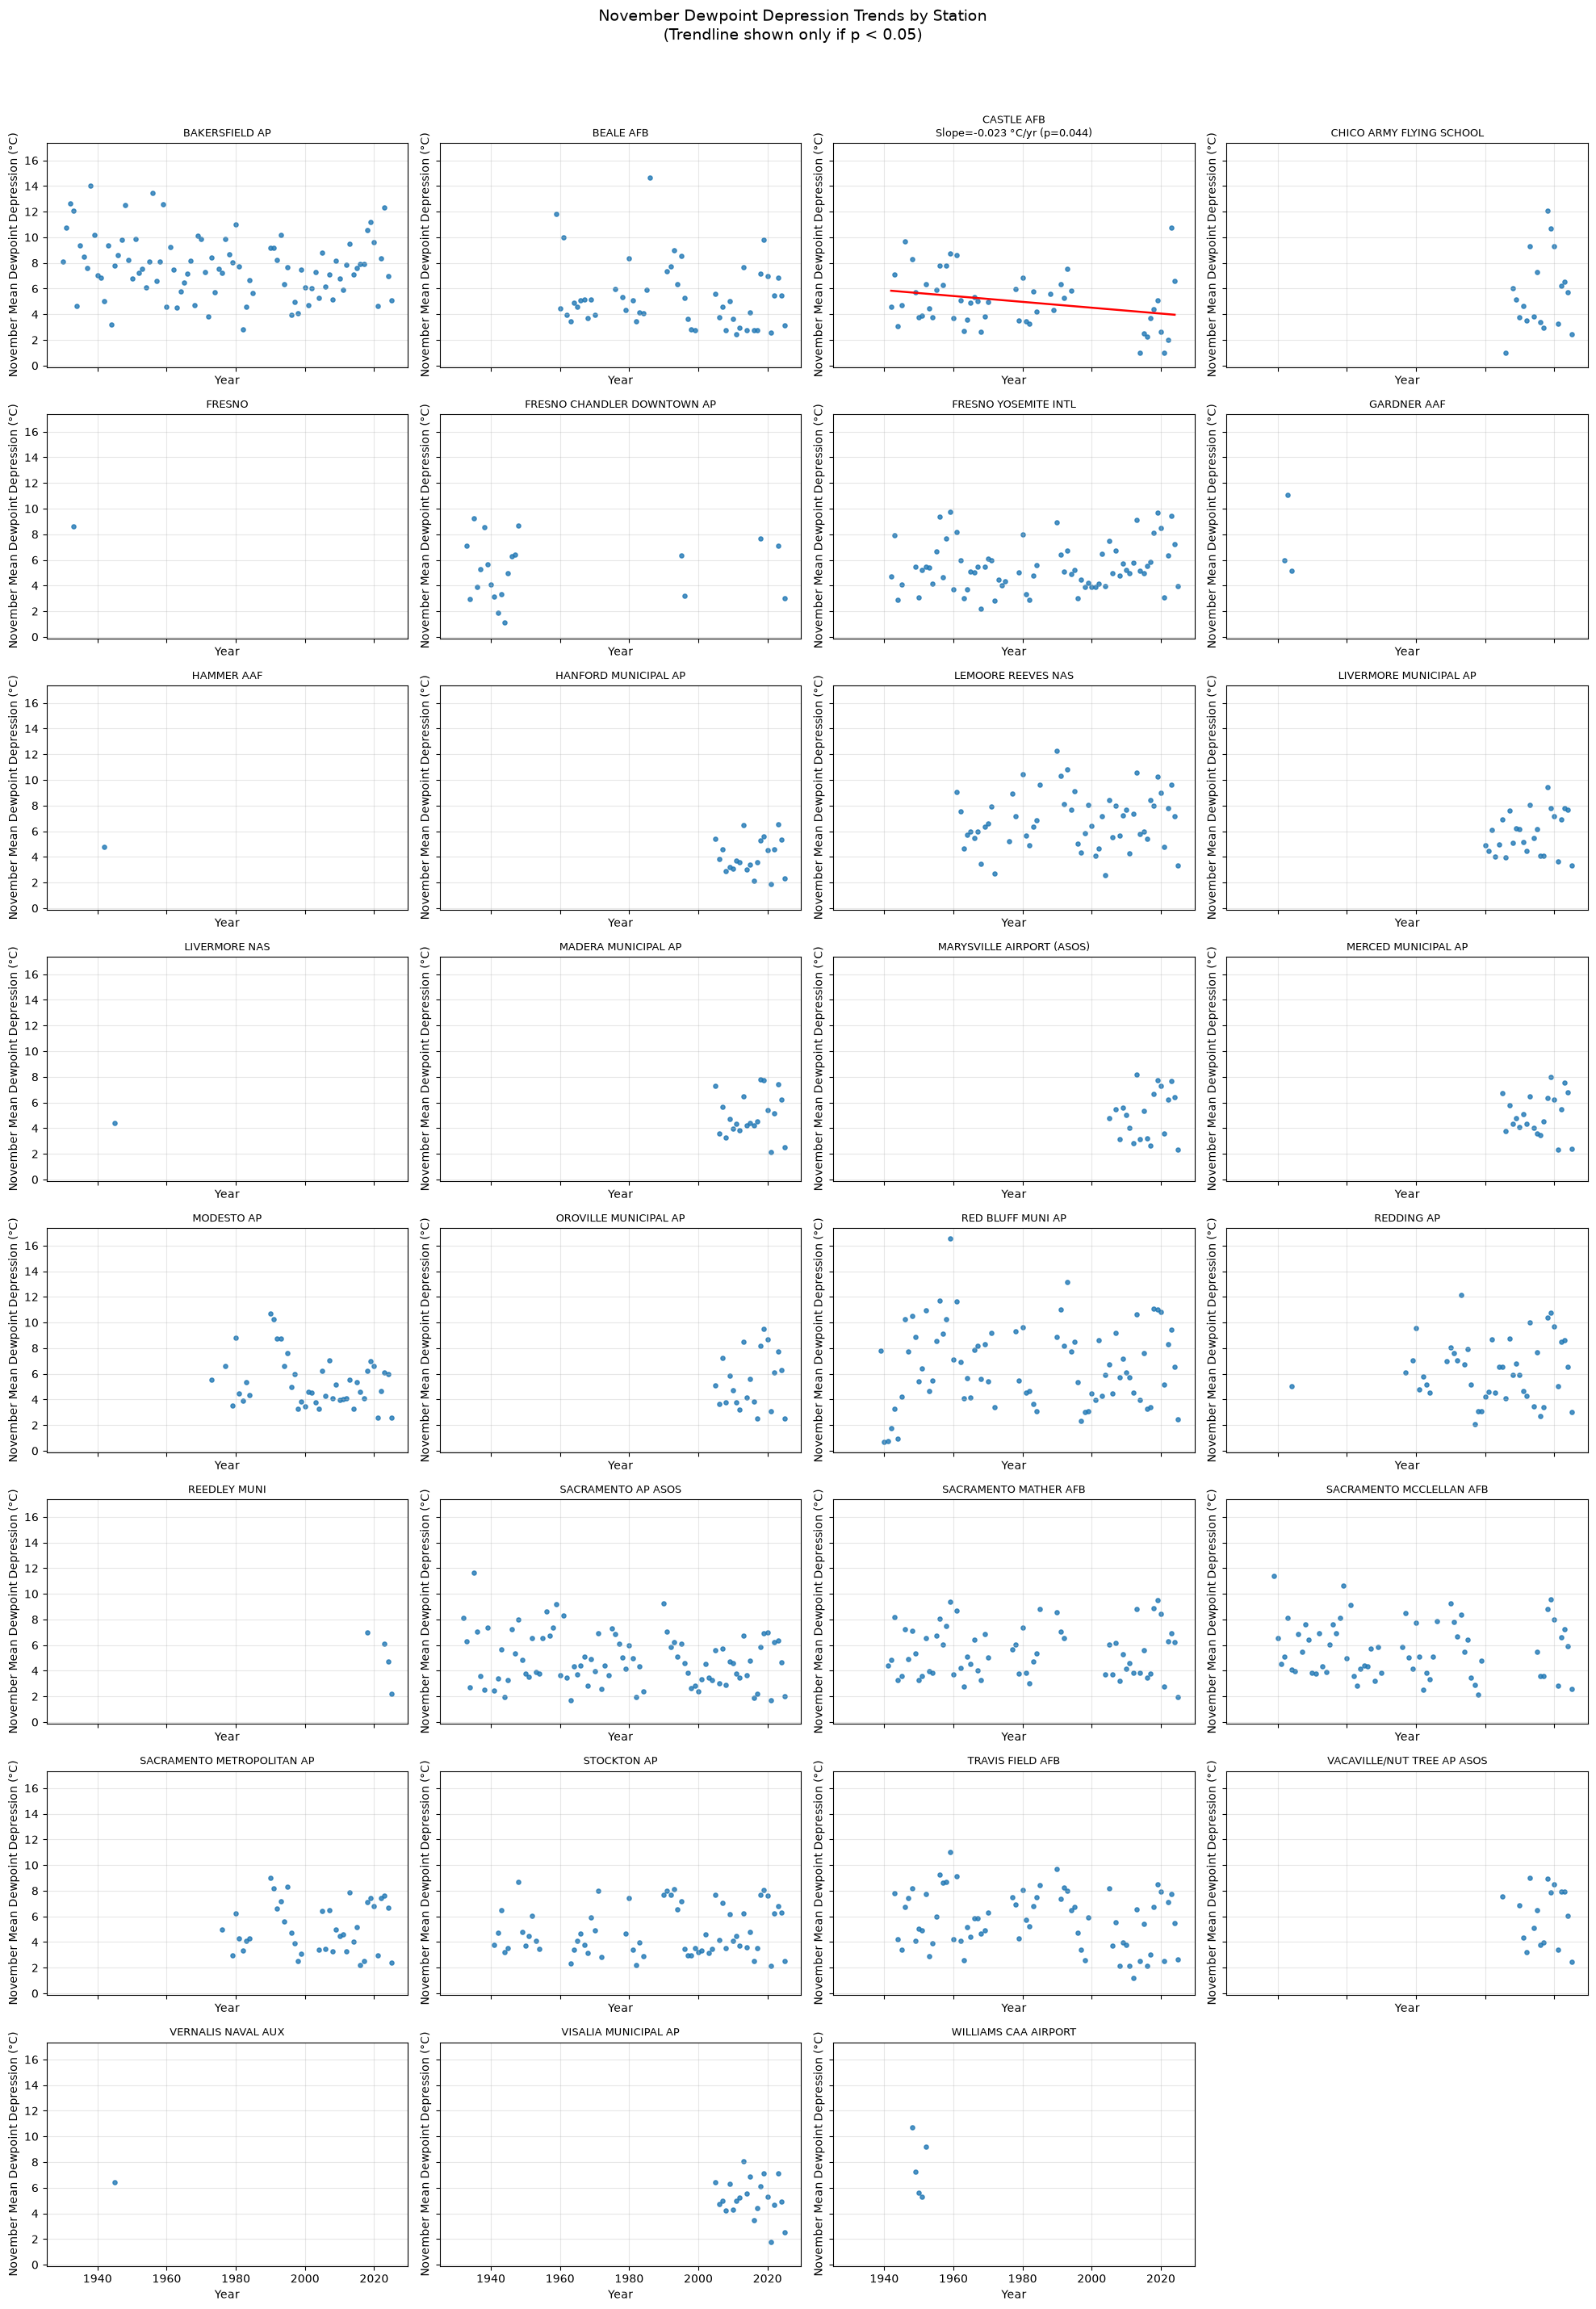

In [8]:
# November mean dewpoint depression by station/year
november_station = (
    monthly_station[monthly_station["month"] == 11]
    .dropna(subset=["HourlyDewpointDepression"])
    .copy()
)

# Trend analysis per station
alpha = 0.05
trend_rows = []

for station_name, g in november_station.groupby("STATION"):
    g = g.sort_values("year")
    if g["year"].nunique() < 2:
        continue

    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    trend_rows.append({
        "STATION": station_name,
        "n_years": g["year"].nunique(),
        "start_year": g["year"].min(),
        "end_year": g["year"].max(),
        "slope_per_year": fit.slope,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue,
        "significant": fit.pvalue < alpha
    })

november_trends = pd.DataFrame(trend_rows).sort_values("slope_per_year")
print(november_trends)

print("\nSignificant trends (p < 0.05):")
print(november_trends[november_trends["significant"]])

# Scatter plots: only significant stations get trendlines
november_stations = sorted(november_station["STATION"].unique())
n_nov_stations = len(november_stations)
ncols = 4
nrows = int(np.ceil(n_nov_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

sig_lookup = november_trends.set_index("STATION")["significant"].to_dict()

for idx, station_name in enumerate(november_stations):
    ax = axes[idx]
    g = november_station[november_station["STATION"] == station_name].sort_values("year")

    ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

    # Draw trendline only if significant
    if g["year"].nunique() >= 2 and sig_lookup.get(station_name, False):
        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        y = fit.intercept + fit.slope * x
        ax.plot(x, y, color="red", linewidth=1.8)
        ax.set_title(f"{station_name}\nSlope={fit.slope:.3f} °C/yr (p={fit.pvalue:.3f})", fontsize=9)
    else:
        ax.set_title(station_name, fontsize=9)

    ax.set_xlabel("Year")
    ax.set_ylabel("November Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for idx in range(n_nov_stations, len(axes)):
    axes[idx].axis("off")

fig.suptitle("November Dewpoint Depression Trends by Station\n(Trendline shown only if p < 0.05)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [9]:

# October data since 1980
october_station_1980 = (
    monthly_station[
        (monthly_station["month"] == 10) &
        (monthly_station["year"] >= 1980)
    ]
    .dropna(subset=["HourlyDewpointDepression"])
    .copy()
)

# Keep only stations with >10 unique years of October data
station_year_counts = october_station_1980.groupby("STATION")["year"].nunique()
eligible_stations = station_year_counts[station_year_counts > 10].index

october_station_1980 = october_station_1980[
    october_station_1980["STATION"].isin(eligible_stations)
]

# Trend per station (slope in °C per year)
trend_rows_1980 = []
for station_name, g in october_station_1980.groupby("STATION"):
    g = g.sort_values("year")
    n_years = g["year"].nunique()
    if n_years <= 10:
        continue

    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    trend_rows_1980.append({
        "STATION": station_name,
        "n_years": n_years,
        "start_year": g["year"].min(),
        "end_year": g["year"].max(),
        "slope_per_year": fit.slope,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue,
        "significant": fit.pvalue < alpha
    })

october_trends_1980 = pd.DataFrame(trend_rows_1980).sort_values("slope_per_year")
print(october_trends_1980)

print("\nStations included:", len(eligible_stations))
print("Significant trends (p < 0.05):")
print(october_trends_1980[october_trends_1980["significant"]])

                       STATION  n_years  start_year  end_year  slope_per_year  \
11                  MODESTO AP       41        1980      2025       -0.011645   
20            TRAVIS FIELD AFB       37        1980      2025       -0.001479   
1                    BEALE AFB       37        1980      2025        0.005647   
22        VISALIA MUNICIPAL AP       21        2005      2025        0.009692   
15          SACRAMENTO AP ASOS       42        1980      2025        0.019841   
5         HANFORD MUNICIPAL AP       21        2005      2025        0.022534   
19                 STOCKTON AP       41        1980      2025        0.032005   
6           LEMOORE REEVES NAS       42        1980      2025        0.032169   
18  SACRAMENTO METROPOLITAN AP       37        1980      2025        0.034790   
2                   CASTLE AFB       24        1980      2025        0.038250   
16       SACRAMENTO MATHER AFB       31        1980      2025        0.039709   
8          MADERA MUNICIPAL 

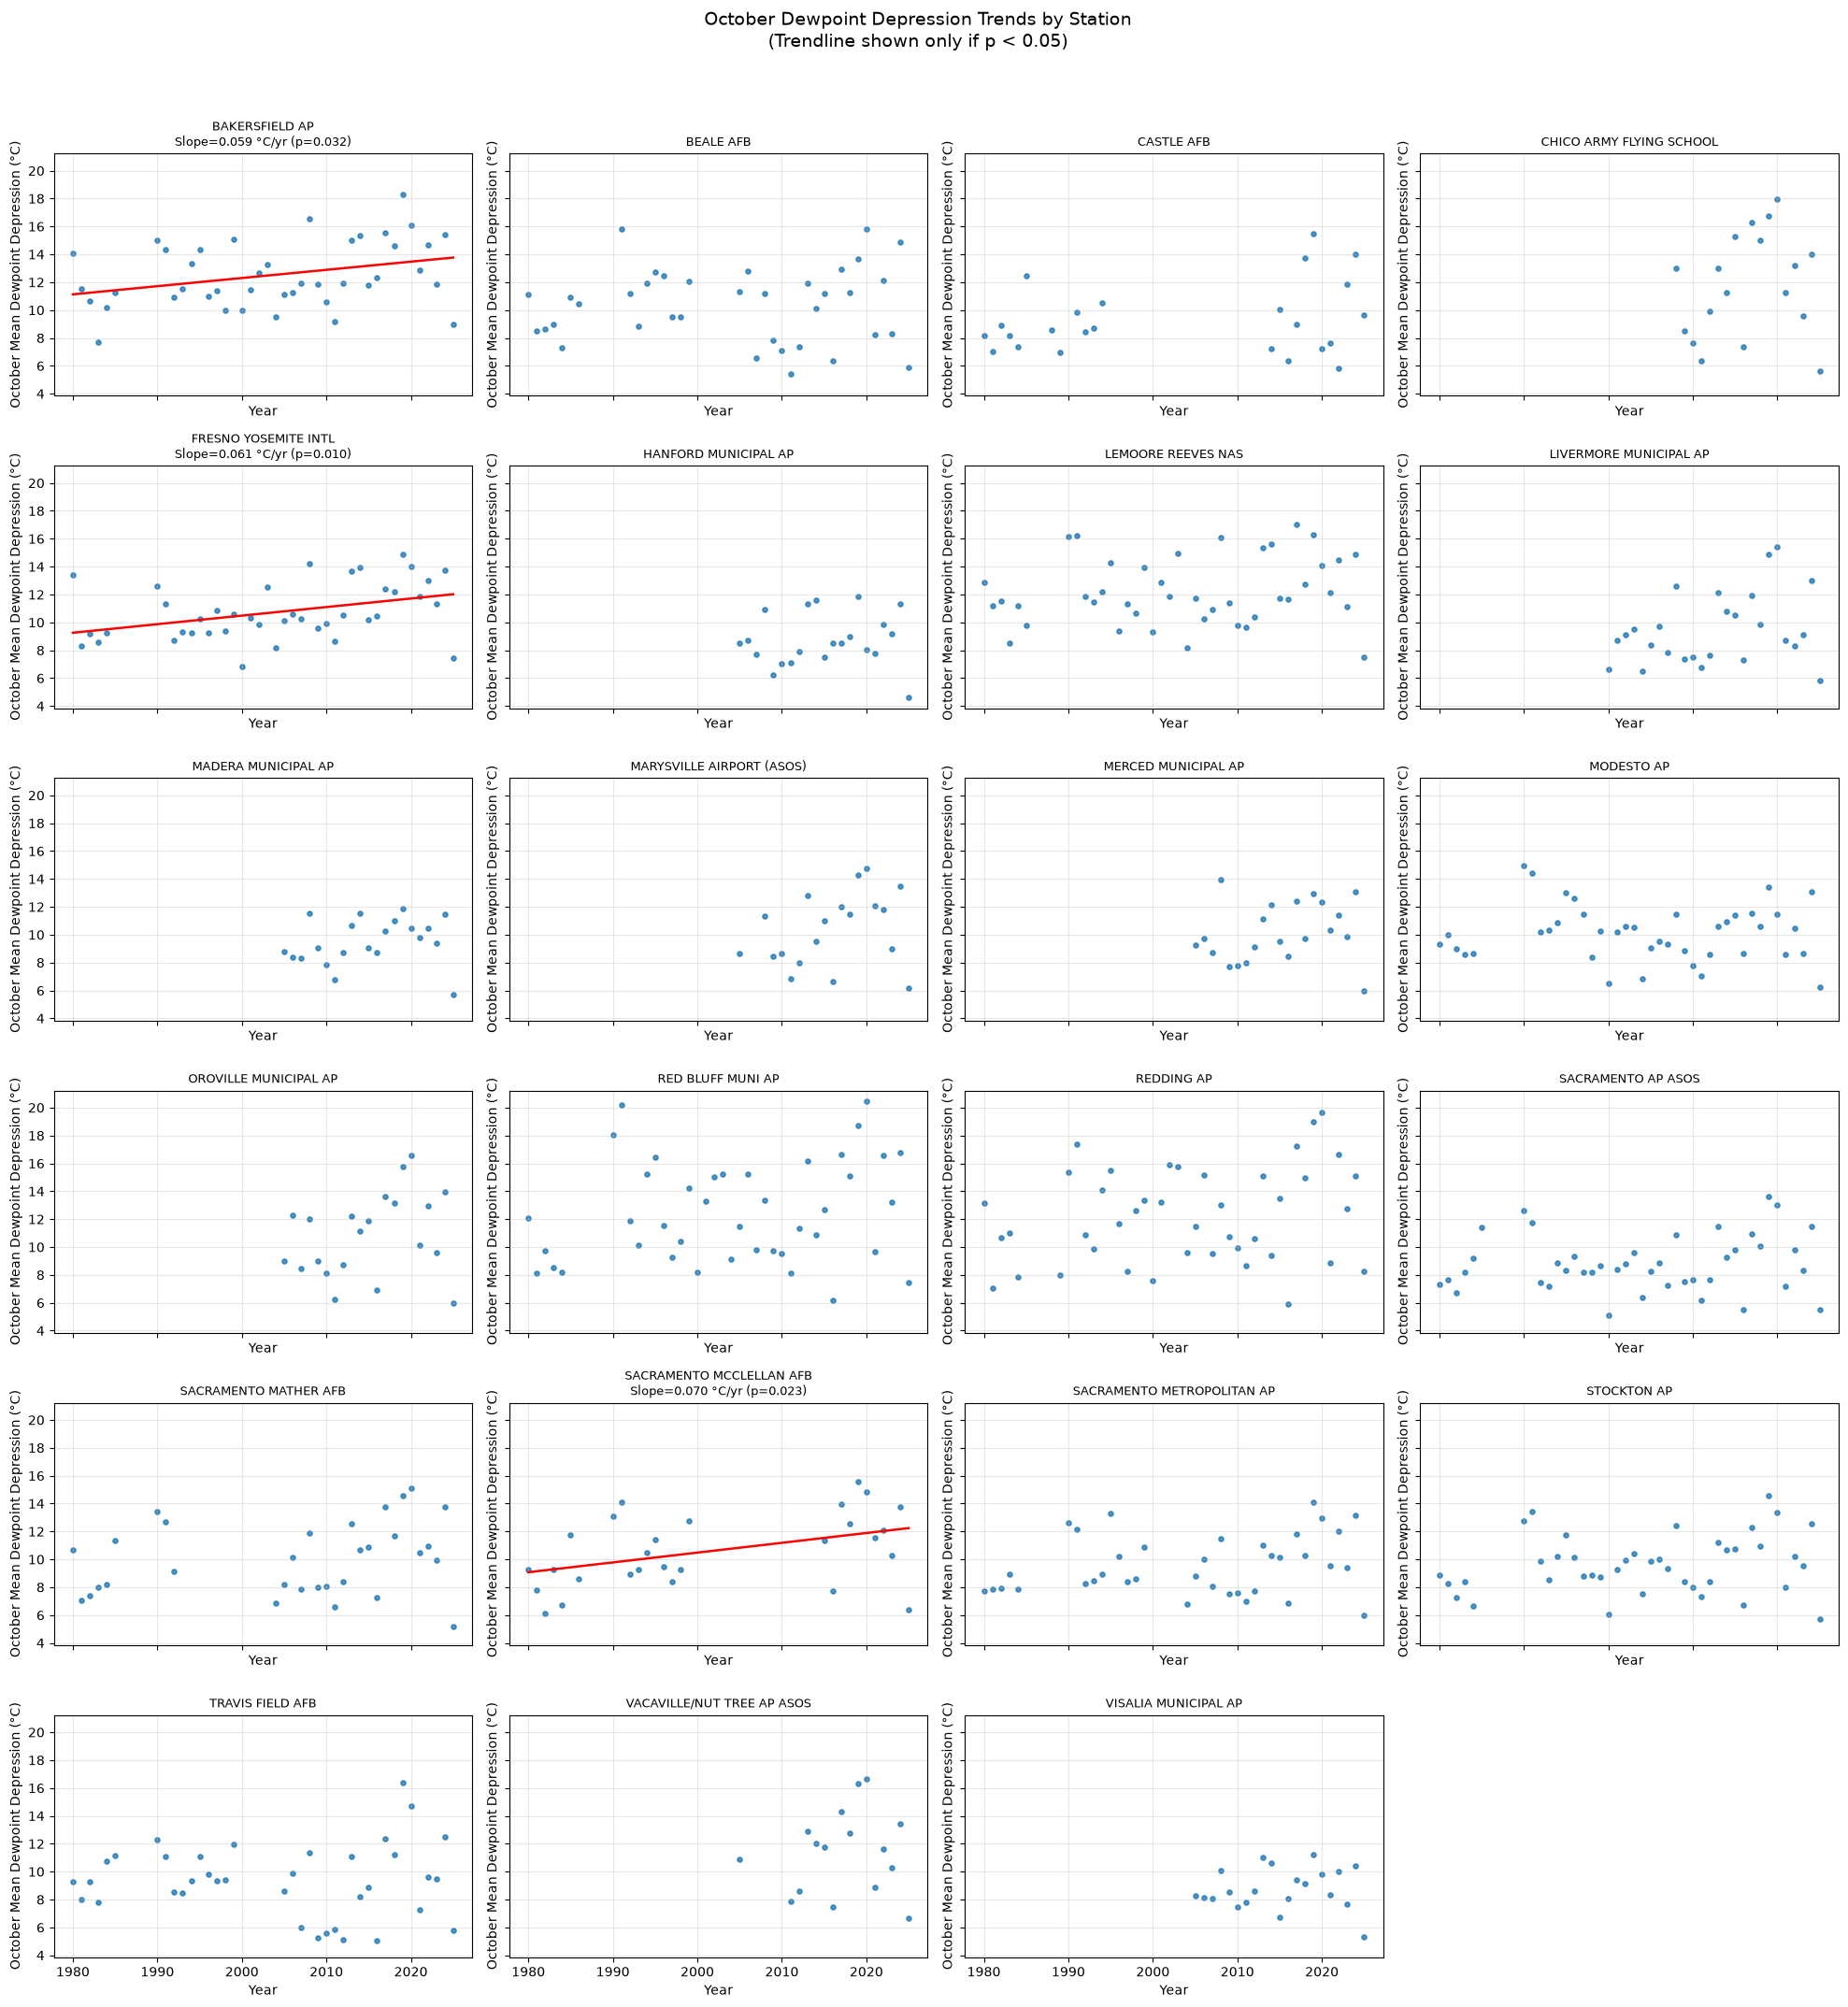

In [10]:
# Scatter plots: only significant stations get trendlines
october_stations = sorted(october_station_1980["STATION"].unique())
n_oct_stations = len(october_station_1980["STATION"].unique())
ncols = 4
nrows = int(np.ceil(n_oct_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

sig_lookup = october_trends_1980.set_index("STATION")["significant"].to_dict()

for idx, station_name in enumerate(october_stations):
    ax = axes[idx]
    g = october_station_1980[october_station_1980["STATION"] == station_name].sort_values("year")

    ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

    # Draw trendline only if significant
    if g["year"].nunique() >= 2 and sig_lookup.get(station_name, False):
        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        y = fit.intercept + fit.slope * x
        ax.plot(x, y, color="red", linewidth=1.8)
        ax.set_title(f"{station_name}\nSlope={fit.slope:.3f} °C/yr (p={fit.pvalue:.3f})", fontsize=9)
    else:
        ax.set_title(station_name, fontsize=9)

    ax.set_xlabel("Year")
    ax.set_ylabel("October Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for idx in range(n_oct_stations, len(axes)):
    axes[idx].axis("off")

fig.suptitle("October Dewpoint Depression Trends by Station\n(Trendline shown only if p < 0.05)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# November data since 1980
# November data since 1980
november_station_1980 = (
    monthly_station[
        (monthly_station["month"] == 11) &
        (monthly_station["year"] >= 1980)
    ]
    .dropna(subset=["HourlyDewpointDepression"])
    .copy()
)

# Keep only stations with >10 unique years of November data
station_year_counts = november_station_1980.groupby("STATION")["year"].nunique()
eligible_stations = station_year_counts[station_year_counts > 10].index

november_station_1980 = november_station_1980[
    november_station_1980["STATION"].isin(eligible_stations)
]

# Trend per station (slope in °C per year)
trend_rows_1980 = []
for station_name, g in november_station_1980.groupby("STATION"):
    g = g.sort_values("year")
    n_years = g["year"].nunique()
    if n_years <= 10:
        continue

    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    trend_rows_1980.append({
        "STATION": station_name,
        "n_years": n_years,
        "start_year": g["year"].min(),
        "end_year": g["year"].max(),
        "slope_per_year": fit.slope,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue,
        "significant": fit.pvalue < alpha
    })

november_trends_1980 = pd.DataFrame(trend_rows_1980).sort_values("slope_per_year")
print(november_trends_1980)

print("\nStations included:", len(eligible_stations))
print("Significant trends (p < 0.05):")
print(november_trends_1980[november_trends_1980["significant"]])

                       STATION  n_years  start_year  end_year  slope_per_year  \
20            TRAVIS FIELD AFB       37        1980      2025       -0.061151   
11                  MODESTO AP       41        1980      2025       -0.049932   
22        VISALIA MUNICIPAL AP       21        2005      2025       -0.048693   
1                    BEALE AFB       37        1980      2025       -0.046587   
2                   CASTLE AFB       22        1980      2024       -0.030165   
21  VACAVILLE/NUT TREE AP ASOS       17        2005      2025       -0.022990   
6           LEMOORE REEVES NAS       42        1980      2025       -0.020321   
15          SACRAMENTO AP ASOS       41        1980      2025       -0.009350   
16       SACRAMENTO MATHER AFB       31        1980      2025       -0.009224   
18  SACRAMENTO METROPOLITAN AP       37        1980      2025       -0.004125   
19                 STOCKTON AP       41        1980      2025        0.004532   
17    SACRAMENTO MCCLELLAN A

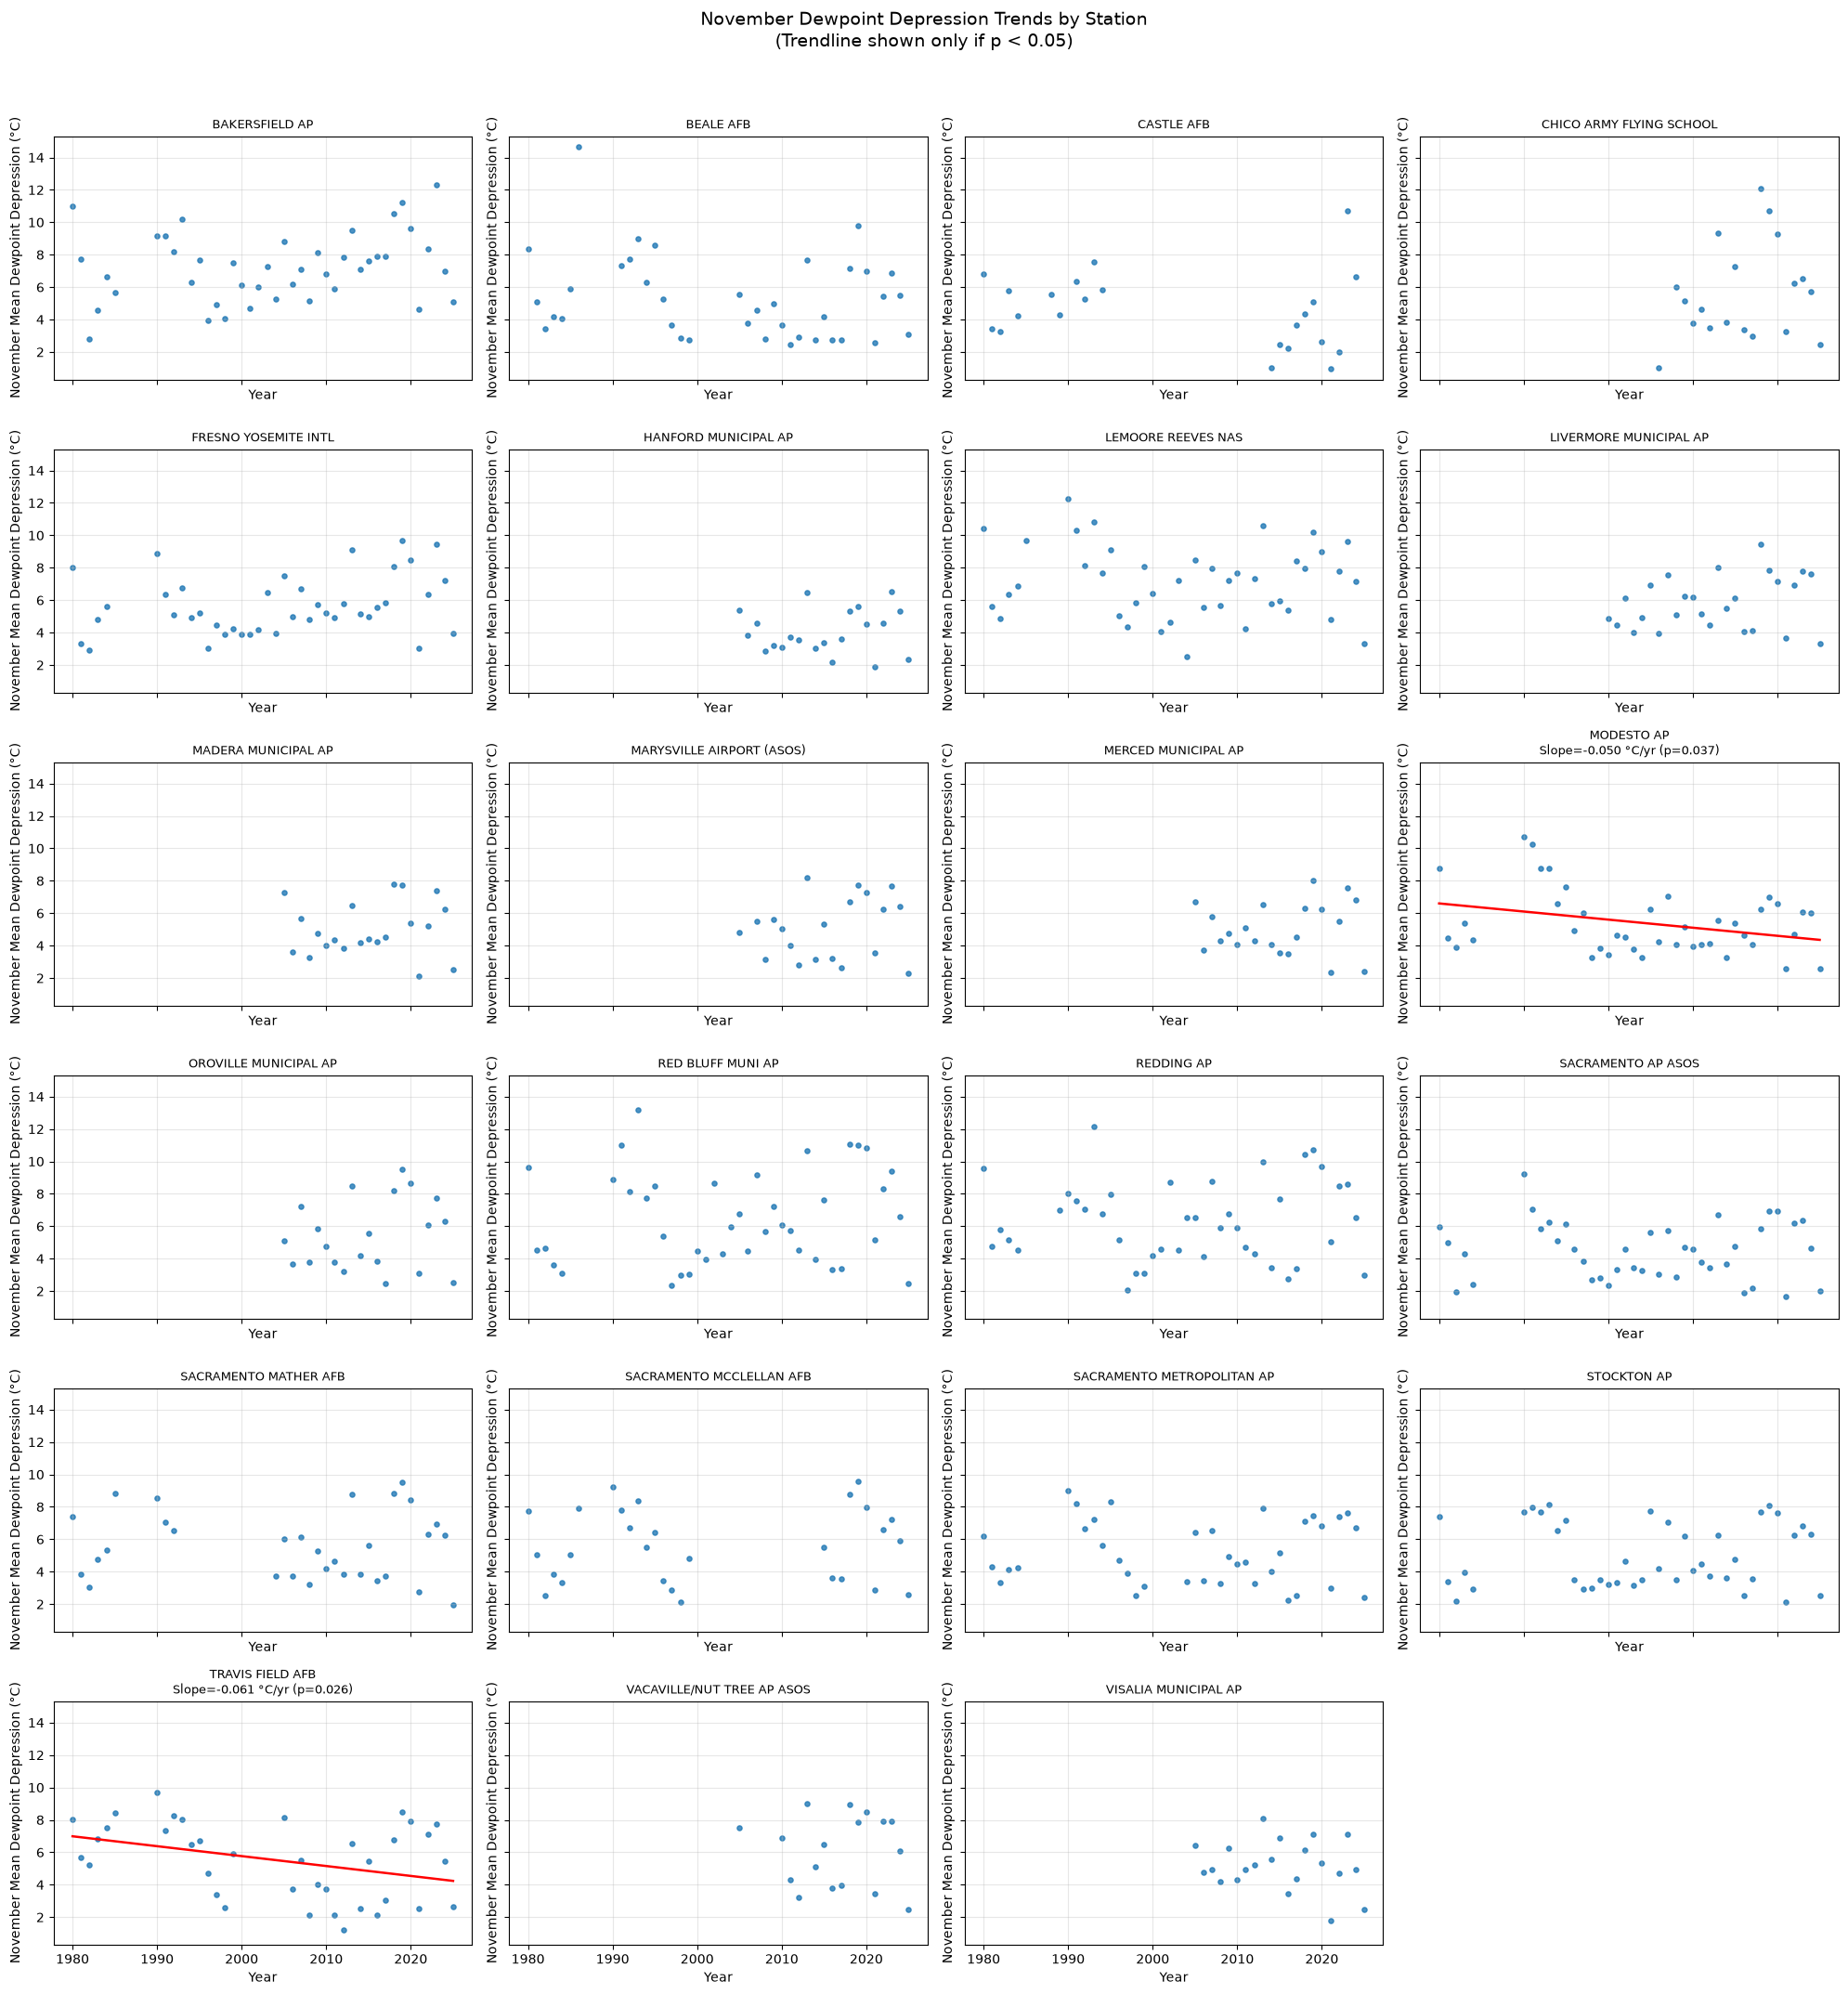

In [12]:
# Scatter plots: only significant stations get trendlines
november_stations = sorted(november_station_1980["STATION"].unique())
n_nov_stations = len(november_station_1980["STATION"].unique())
ncols = 4
nrows = int(np.ceil(n_nov_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

sig_lookup = november_trends_1980.set_index("STATION")["significant"].to_dict()

for idx, station_name in enumerate(november_stations):
    ax = axes[idx]
    g = november_station_1980[november_station_1980["STATION"] == station_name].sort_values("year")

    ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

    # Draw trendline only if significant
    if g["year"].nunique() >= 2 and sig_lookup.get(station_name, False):
        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        y = fit.intercept + fit.slope * x
        ax.plot(x, y, color="red", linewidth=1.8)
        ax.set_title(f"{station_name}\nSlope={fit.slope:.3f} °C/yr (p={fit.pvalue:.3f})", fontsize=9)
    else:
        ax.set_title(station_name, fontsize=9)

    ax.set_xlabel("Year")
    ax.set_ylabel("November Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for idx in range(n_nov_stations, len(axes)):
    axes[idx].axis("off")

fig.suptitle("November Dewpoint Depression Trends by Station\n(Trendline shown only if p < 0.05)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# December data since 1980
december_station_1980 = (
    monthly_station[
        (monthly_station["month"] == 12) &
        (monthly_station["year"] >= 1980)
    ]
    .dropna(subset=["HourlyDewpointDepression"])
    .copy()
)

# Keep only stations with >10 unique years of December data
station_year_counts = december_station_1980.groupby("STATION")["year"].nunique()
eligible_stations = station_year_counts[station_year_counts > 10].index

december_station_1980 = december_station_1980[
    december_station_1980["STATION"].isin(eligible_stations)
]

# Trend per station (slope in °C per year)
trend_rows_1980 = []
for station_name, g in december_station_1980.groupby("STATION"):
    g = g.sort_values("year")
    n_years = g["year"].nunique()
    if n_years <= 10:
        continue

    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    trend_rows_1980.append({
        "STATION": station_name,
        "n_years": n_years,
        "start_year": g["year"].min(),
        "end_year": g["year"].max(),
        "slope_per_year": fit.slope,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue,
        "significant": fit.pvalue < alpha
    })

december_trends_1980 = pd.DataFrame(trend_rows_1980).sort_values("slope_per_year")
print(december_trends_1980)

print("\nStations included:", len(eligible_stations))
print("Significant trends (p < 0.05):")
print(december_trends_1980[december_trends_1980["significant"]])

                       STATION  n_years  start_year  end_year  slope_per_year  \
22        VISALIA MUNICIPAL AP       22        2004      2025       -0.112856   
3     CHICO ARMY FLYING SCHOOL       18        2008      2025       -0.096102   
21  VACAVILLE/NUT TREE AP ASOS       18        2004      2025       -0.048756   
20            TRAVIS FIELD AFB       41        1980      2025       -0.047689   
1                    BEALE AFB       41        1980      2025       -0.039273   
6           LEMOORE REEVES NAS       44        1980      2025       -0.028191   
17    SACRAMENTO MCCLELLAN AFB       32        1980      2025       -0.026192   
2                   CASTLE AFB       27        1980      2025       -0.024726   
11                  MODESTO AP       46        1980      2025       -0.021961   
10         MERCED MUNICIPAL AP       22        2004      2025       -0.021841   
7       LIVERMORE MUNICIPAL AP       27        1999      2025       -0.020257   
5         HANFORD MUNICIPAL 

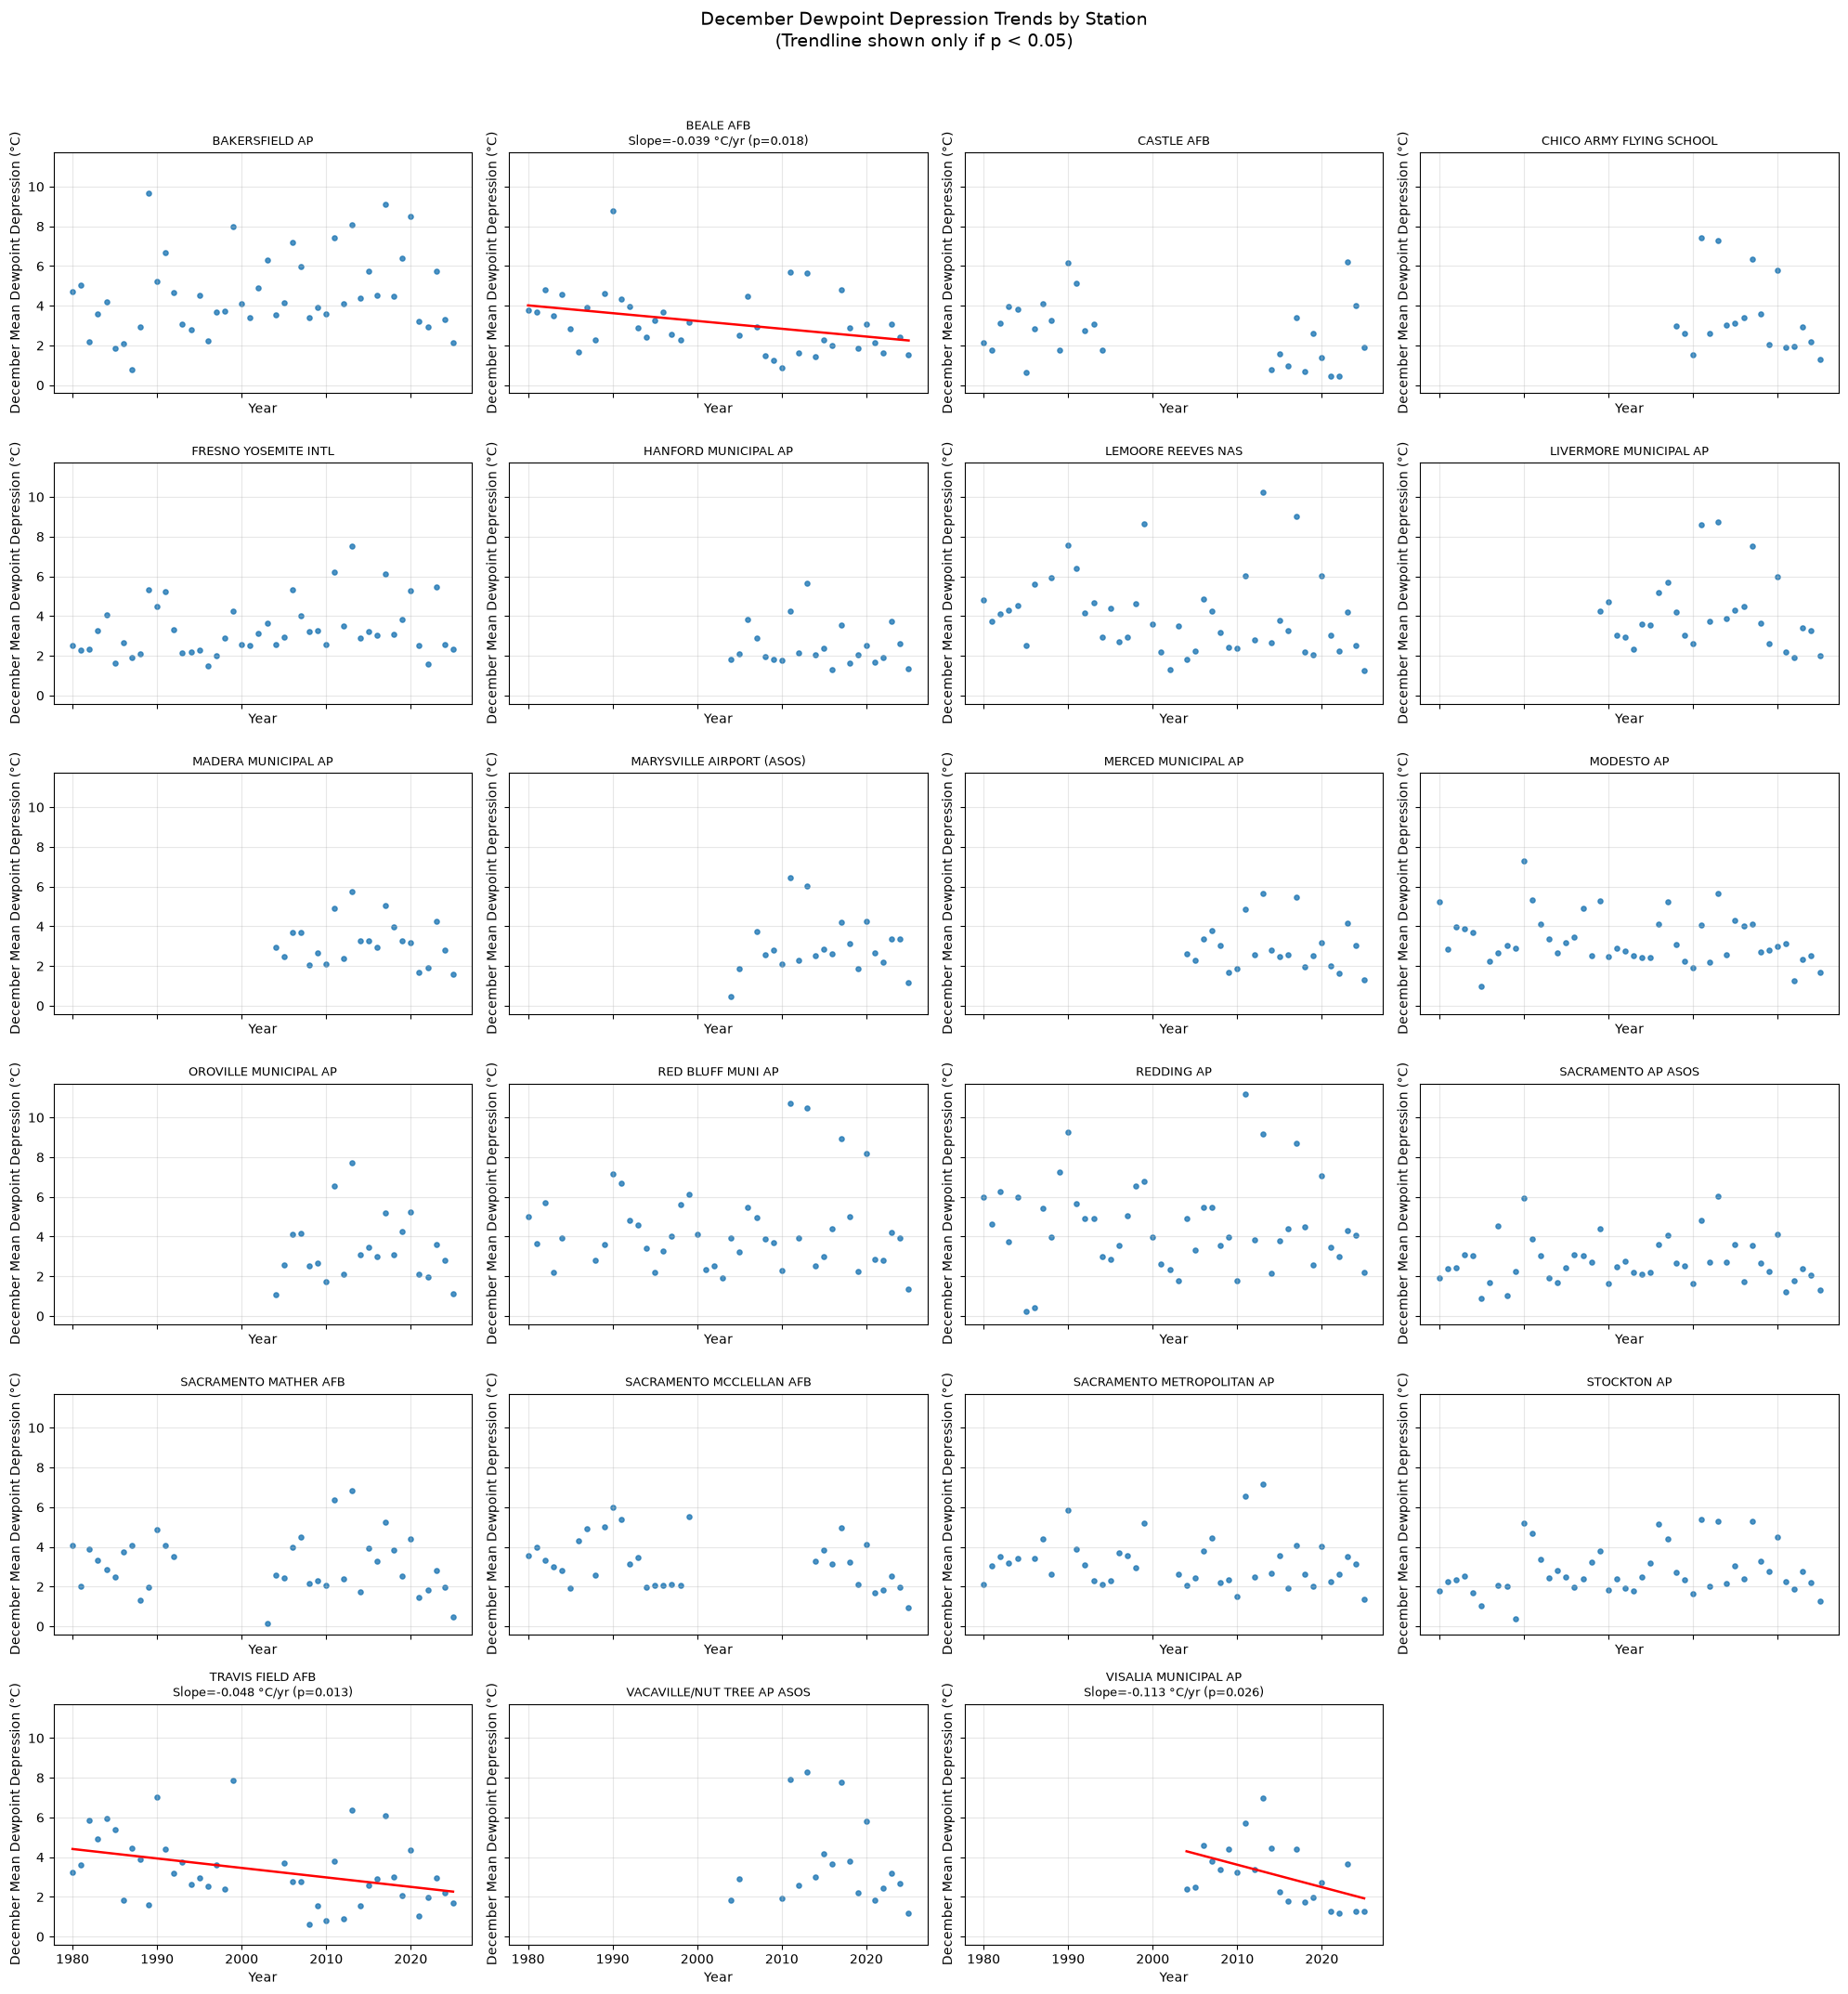

In [14]:
# Scatter plots: only significant stations get trendlines
december_stations = sorted(december_station_1980["STATION"].unique())
n_dec_stations = len(december_station_1980["STATION"].unique())
ncols = 4
nrows = int(np.ceil(n_dec_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

sig_lookup = december_trends_1980.set_index("STATION")["significant"].to_dict()

for idx, station_name in enumerate(december_stations):
    ax = axes[idx]
    g = december_station_1980[december_station_1980["STATION"] == station_name].sort_values("year")

    ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

    # Draw trendline only if significant
    if g["year"].nunique() >= 2 and sig_lookup.get(station_name, False):
        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        y = fit.intercept + fit.slope * x
        ax.plot(x, y, color="red", linewidth=1.8)
        ax.set_title(f"{station_name}\nSlope={fit.slope:.3f} °C/yr (p={fit.pvalue:.3f})", fontsize=9)
    else:
        ax.set_title(station_name, fontsize=9)

    ax.set_xlabel("Year")
    ax.set_ylabel("December Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for idx in range(n_dec_stations, len(axes)):
    axes[idx].axis("off")

fig.suptitle("December Dewpoint Depression Trends by Station\n(Trendline shown only if p < 0.05)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# January data since 1980
january_station_1980 = (
    monthly_station[
        (monthly_station["month"] == 1) &
        (monthly_station["year"] >= 1980)
    ]
    .dropna(subset=["HourlyDewpointDepression"])
    .copy()
)

# Keep only stations with >10 unique years of January data
station_year_counts = january_station_1980.groupby("STATION")["year"].nunique()
eligible_stations = station_year_counts[station_year_counts > 10].index

january_station_1980 = january_station_1980[
    january_station_1980["STATION"].isin(eligible_stations)
]

# Trend per station (slope in °C per year)
trend_rows_1980 = []
for station_name, g in january_station_1980.groupby("STATION"):
    g = g.sort_values("year")
    n_years = g["year"].nunique()
    if n_years <= 10:
        continue

    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    trend_rows_1980.append({
        "STATION": station_name,
        "n_years": n_years,
        "start_year": g["year"].min(),
        "end_year": g["year"].max(),
        "slope_per_year": fit.slope,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue,
        "significant": fit.pvalue < alpha
    })

january_trends_1980 = pd.DataFrame(trend_rows_1980).sort_values("slope_per_year")
print(january_trends_1980)

print("\nStations included:", len(eligible_stations))
print("Significant trends (p < 0.05):")
print(january_trends_1980[january_trends_1980["significant"]])

                       STATION  n_years  start_year  end_year  slope_per_year  \
3     CHICO ARMY FLYING SCHOOL       18        2007      2026       -0.203447   
22        VISALIA MUNICIPAL AP       22        2005      2026       -0.118559   
20            TRAVIS FIELD AFB       41        1980      2026       -0.027039   
6           LEMOORE REEVES NAS       47        1980      2026       -0.016991   
2                   CASTLE AFB       27        1980      2025       -0.016091   
1                    BEALE AFB       41        1980      2026       -0.015192   
11                  MODESTO AP       45        1982      2026       -0.009479   
5         HANFORD MUNICIPAL AP       22        2005      2026       -0.002188   
10         MERCED MUNICIPAL AP       22        2005      2026        0.000882   
17    SACRAMENTO MCCLELLAN AFB       32        1980      2026        0.001306   
16       SACRAMENTO MATHER AFB       37        1980      2026        0.006751   
14                  REDDING 

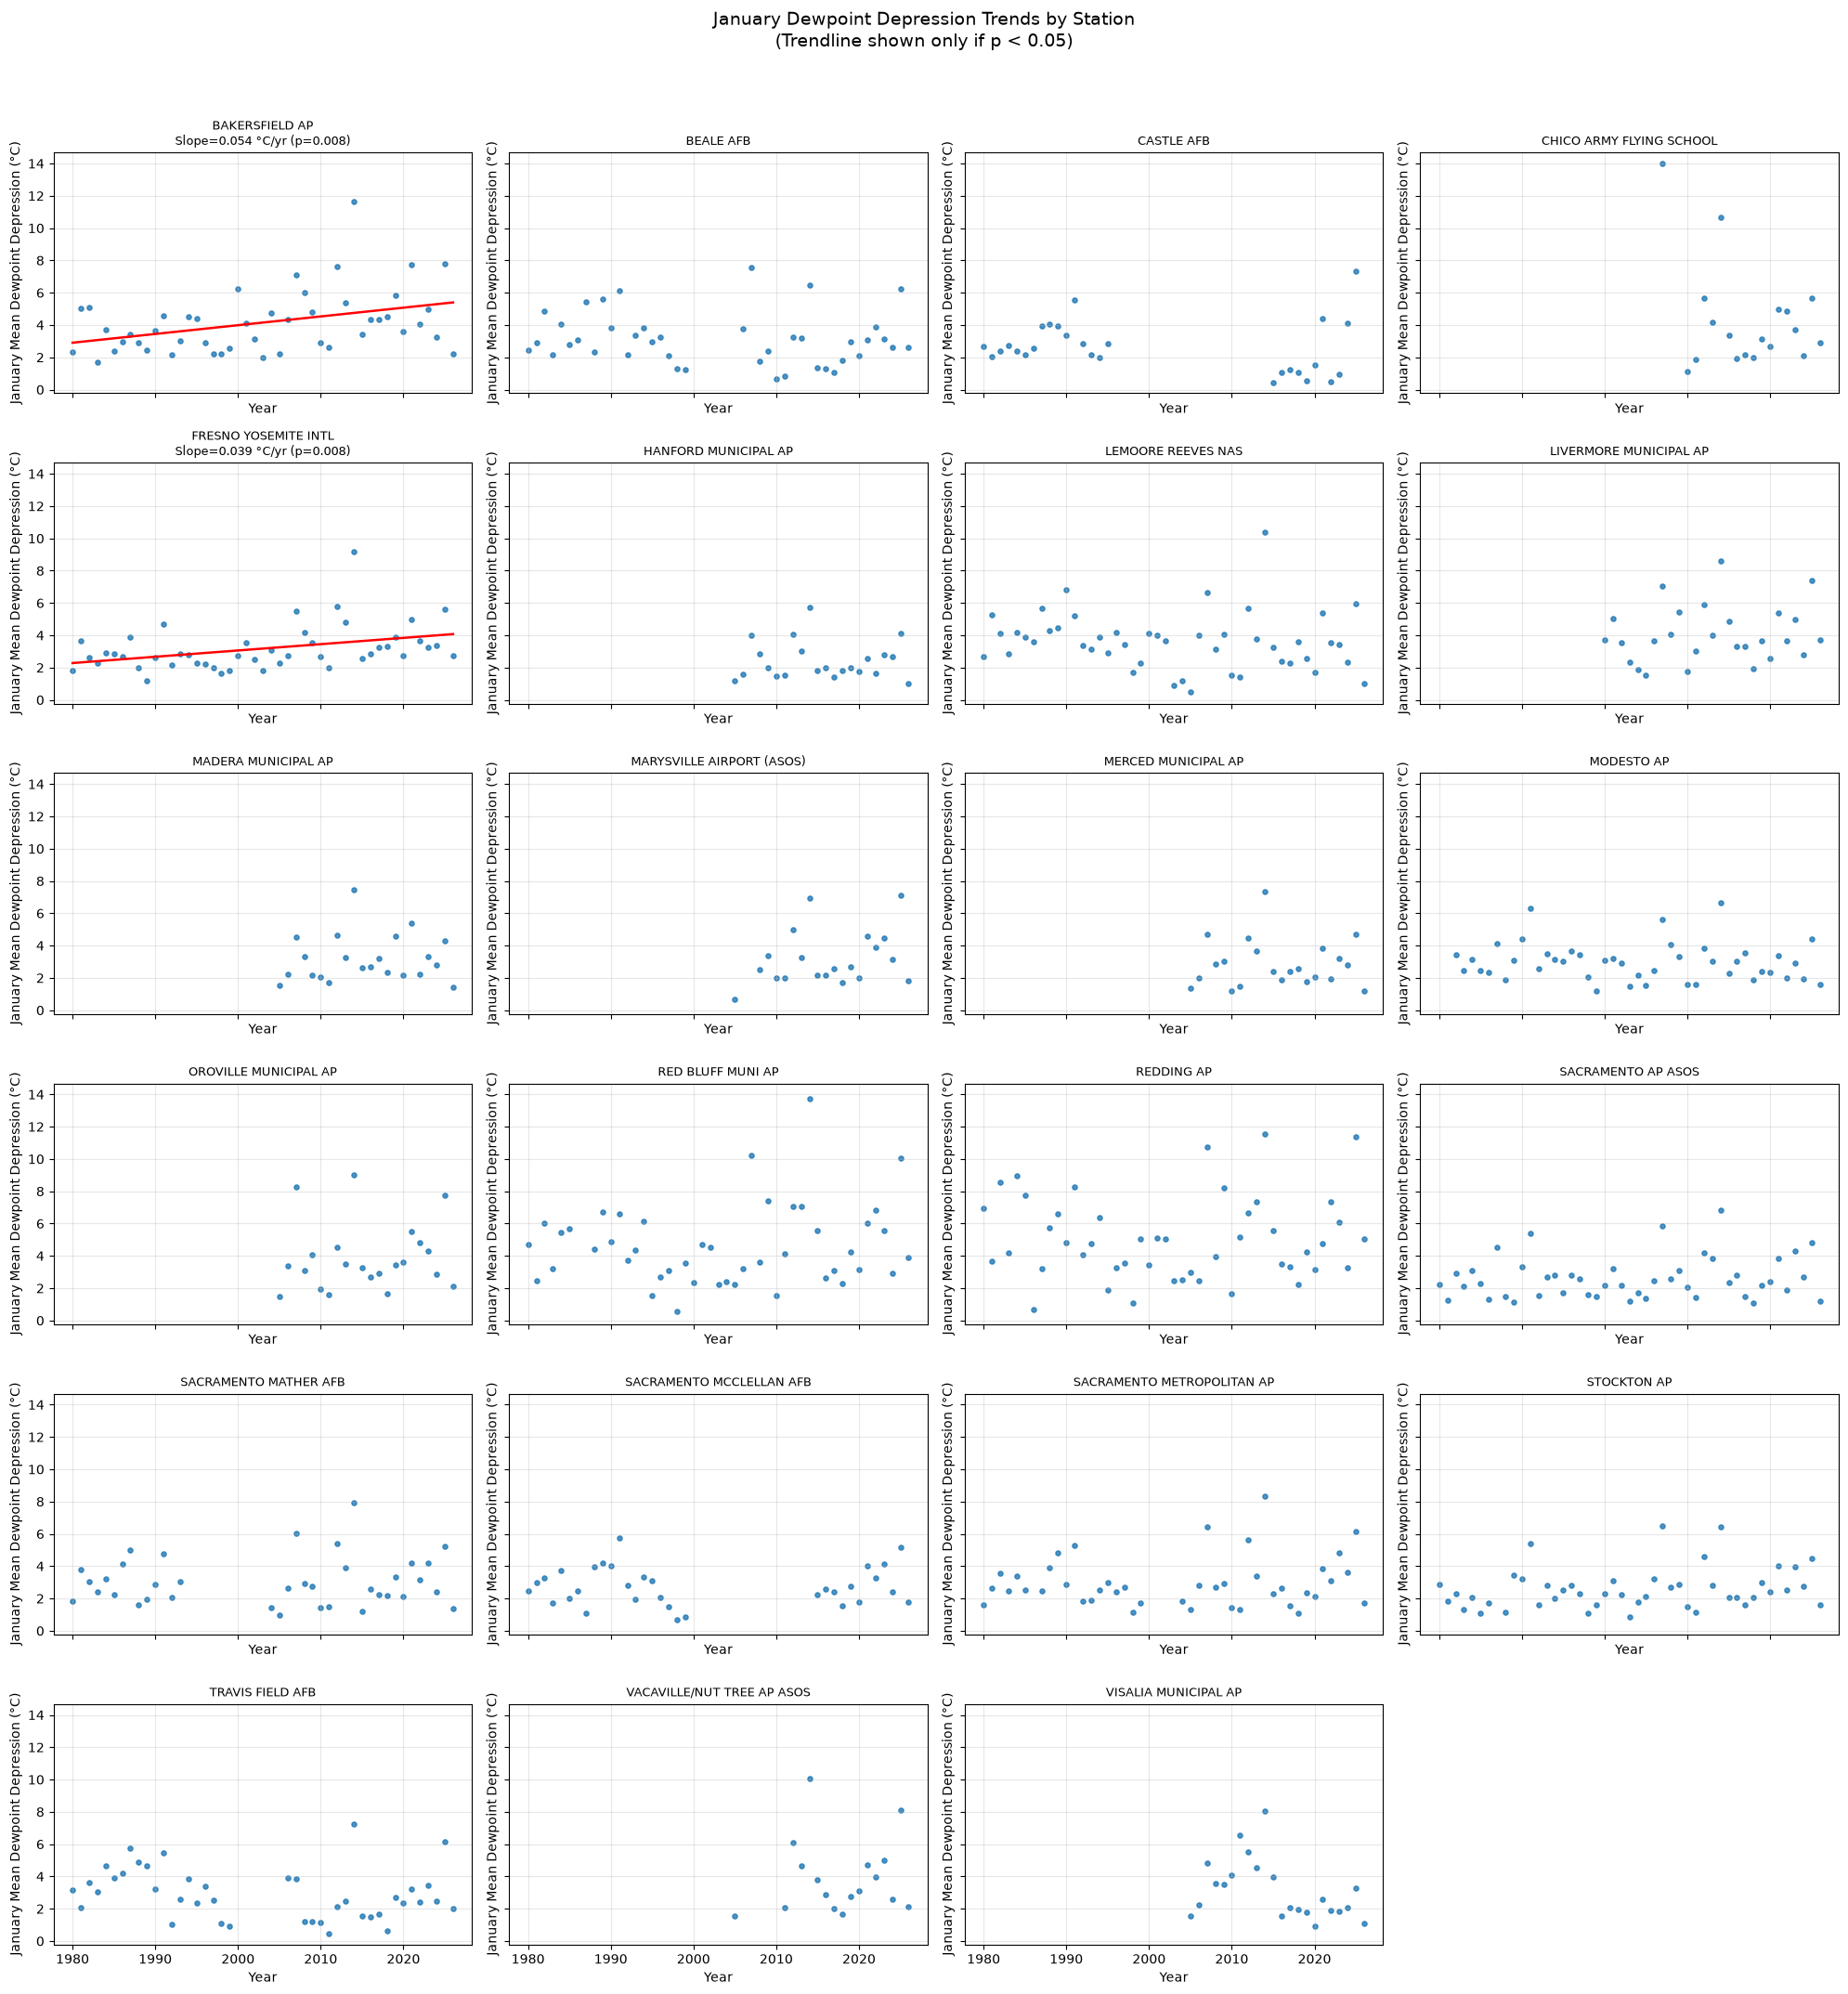

In [16]:
# Scatter plots: only significant stations get trendlines
january_stations = sorted(january_station_1980["STATION"].unique())
n_jan_stations = len(january_station_1980["STATION"].unique())
ncols = 4
nrows = int(np.ceil(n_jan_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

sig_lookup = january_trends_1980.set_index("STATION")["significant"].to_dict()

for idx, station_name in enumerate(january_stations):
    ax = axes[idx]
    g = january_station_1980[january_station_1980["STATION"] == station_name].sort_values("year")

    ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

    # Draw trendline only if significant
    if g["year"].nunique() >= 2 and sig_lookup.get(station_name, False):
        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        y = fit.intercept + fit.slope * x
        ax.plot(x, y, color="red", linewidth=1.8)
        ax.set_title(f"{station_name}\nSlope={fit.slope:.3f} °C/yr (p={fit.pvalue:.3f})", fontsize=9)
    else:
        ax.set_title(station_name, fontsize=9)

    ax.set_xlabel("Year")
    ax.set_ylabel("January Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for idx in range(n_jan_stations, len(axes)):
    axes[idx].axis("off")

fig.suptitle("January Dewpoint Depression Trends by Station\n(Trendline shown only if p < 0.05)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
# February data since 1980
february_station_1980 = (
    monthly_station[
        (monthly_station["month"] == 2) &
        (monthly_station["year"] >= 1980)
    ]
    .dropna(subset=["HourlyDewpointDepression"])
    .copy()
)

# Keep only stations with >10 unique years of February data
station_year_counts = february_station_1980.groupby("STATION")["year"].nunique()
eligible_stations = station_year_counts[station_year_counts > 10].index

february_station_1980 = february_station_1980[
    february_station_1980["STATION"].isin(eligible_stations)
]

# Trend per station (slope in °C per year)
trend_rows_1980 = []
for station_name, g in february_station_1980.groupby("STATION"):
    g = g.sort_values("year")
    n_years = g["year"].nunique()
    if n_years <= 10:
        continue

    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    trend_rows_1980.append({
        "STATION": station_name,
        "n_years": n_years,
        "start_year": g["year"].min(),
        "end_year": g["year"].max(),
        "slope_per_year": fit.slope,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue,
        "significant": fit.pvalue < alpha
    })

february_trends_1980 = pd.DataFrame(trend_rows_1980).sort_values("slope_per_year")
print(february_trends_1980)

print("\nStations included:", len(eligible_stations))
print("Significant trends (p < 0.05):")
print(february_trends_1980[february_trends_1980["significant"]])

                       STATION  n_years  start_year  end_year  slope_per_year  \
22        VISALIA MUNICIPAL AP       22        2005      2026       -0.029106   
20            TRAVIS FIELD AFB       40        1980      2026       -0.018654   
1                    BEALE AFB       41        1980      2026       -0.011682   
14                  REDDING AP       45        1980      2026       -0.006706   
11                  MODESTO AP       43        1981      2026       -0.002659   
16       SACRAMENTO MATHER AFB       34        1980      2026        0.010217   
17    SACRAMENTO MCCLELLAN AFB       30        1980      2026        0.015373   
6           LEMOORE REEVES NAS       44        1980      2026        0.017172   
15          SACRAMENTO AP ASOS       43        1980      2026        0.024093   
18  SACRAMENTO METROPOLITAN AP       39        1980      2026        0.027687   
19                 STOCKTON AP       44        1980      2026        0.031434   
3     CHICO ARMY FLYING SCHO

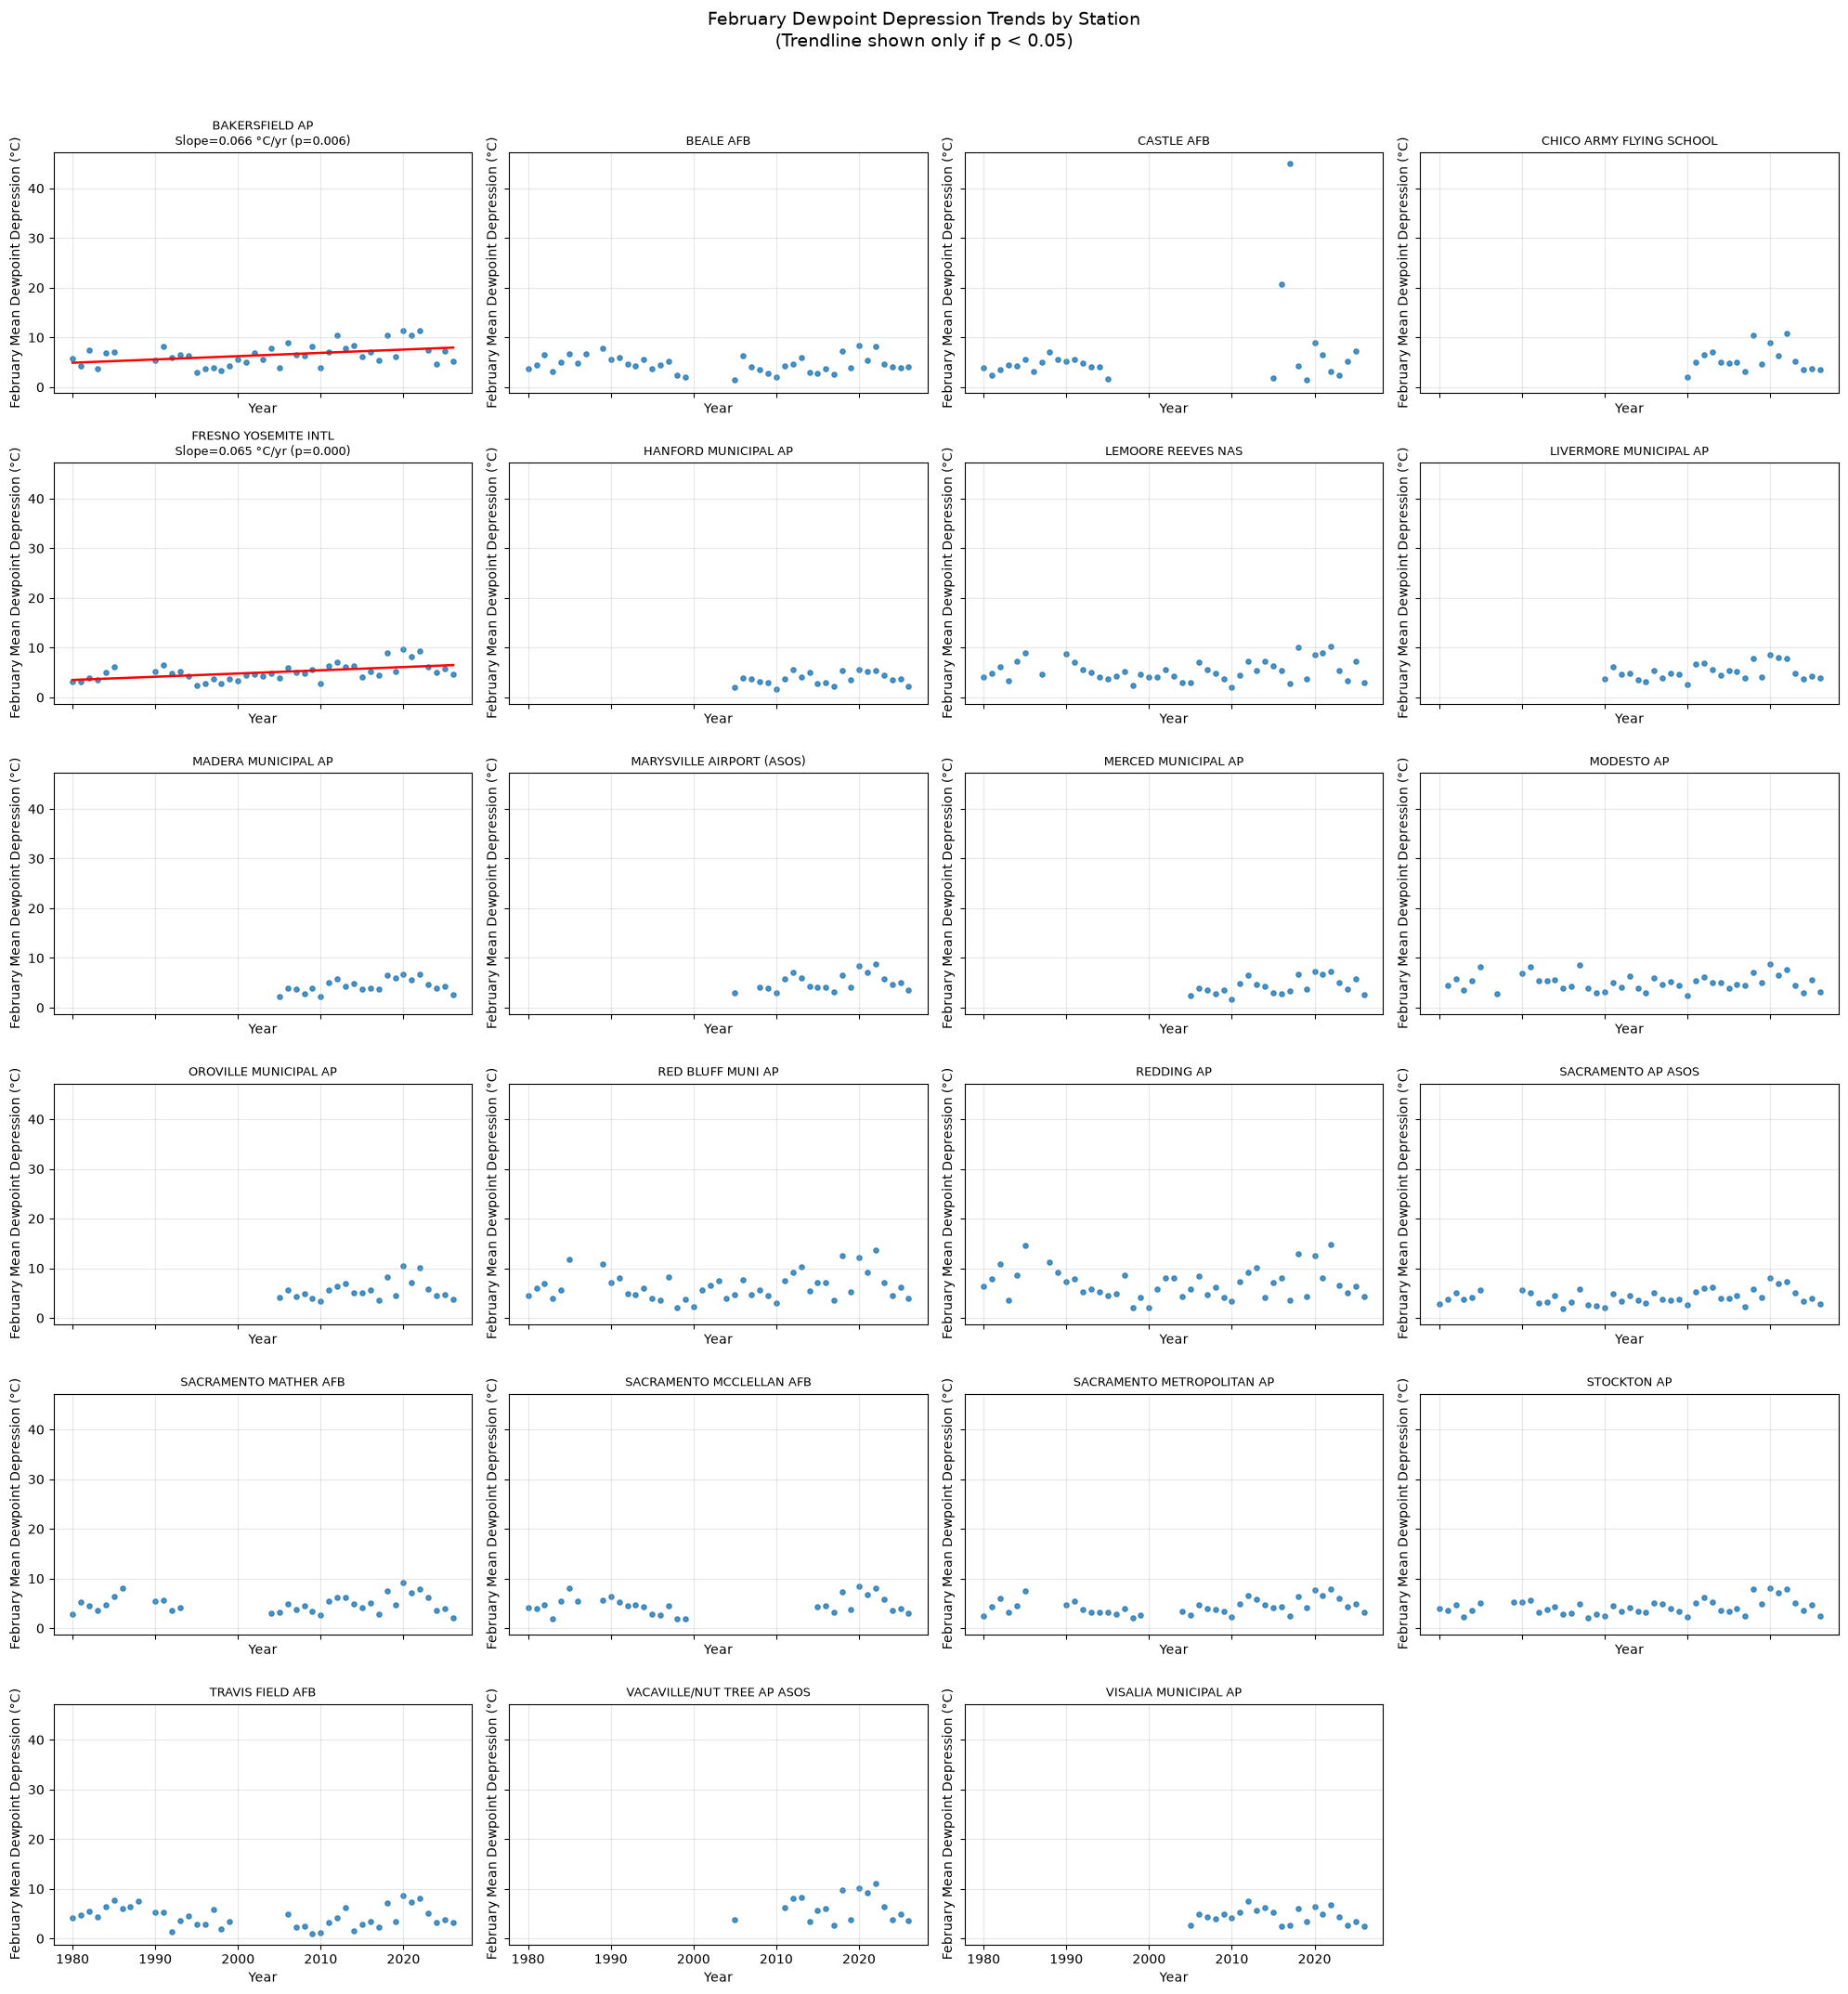

In [19]:
# Scatter plots: only significant stations get trendlines
n_feb_stations = len(february_station_1980["STATION"].unique())
february_stations = sorted(february_station_1980["STATION"].unique())
ncols = 4
nrows = int(np.ceil(n_feb_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

sig_lookup = february_trends_1980.set_index("STATION")["significant"].to_dict()

for idx, station_name in enumerate(february_stations):
    ax = axes[idx]
    g = february_station_1980[february_station_1980["STATION"] == station_name].sort_values("year")

    ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

    # Draw trendline only if significant
    if g["year"].nunique() >= 2 and sig_lookup.get(station_name, False):
        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        y = fit.intercept + fit.slope * x
        ax.plot(x, y, color="red", linewidth=1.8)
        ax.set_title(f"{station_name}\nSlope={fit.slope:.3f} °C/yr (p={fit.pvalue:.3f})", fontsize=9)
    else:
        ax.set_title(station_name, fontsize=9)

    ax.set_xlabel("Year")
    ax.set_ylabel("February Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for idx in range(n_feb_stations, len(axes)):
    axes[idx].axis("off")

fig.suptitle("February Dewpoint Depression Trends by Station\n(Trendline shown only if p < 0.05)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# March data since 1980
march_station_1980 = (
    monthly_station[
        (monthly_station["month"] == 3) &
        (monthly_station["year"] >= 1980)
    ]
    .dropna(subset=["HourlyDewpointDepression"])
    .copy()
)

# Keep only stations with >10 unique years of March data
station_year_counts = march_station_1980.groupby("STATION")["year"].nunique()
eligible_stations = station_year_counts[station_year_counts > 10].index

march_station_1980 = march_station_1980[
    march_station_1980["STATION"].isin(eligible_stations)
]

# Trend per station (slope in °C per year)
trend_rows_1980 = []
for station_name, g in march_station_1980.groupby("STATION"):
    g = g.sort_values("year")
    n_years = g["year"].nunique()
    if n_years <= 10:
        continue  # Skip stations with <= 10 years of data

    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    trend_rows_1980.append({
        "STATION": station_name,
        "n_years": n_years,
        "start_year": g["year"].min(),
        "end_year": g["year"].max(),
        "slope_per_year": fit.slope,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue,
        "significant": fit.pvalue < alpha
    })

march_trends_1980 = pd.DataFrame(trend_rows_1980).sort_values("slope_per_year")
print(march_trends_1980)

print("\nStations included:", len(eligible_stations))
print("Significant trends (p < 0.05):")
print(march_trends_1980[march_trends_1980["significant"]])

                       STATION  n_years  start_year  end_year  slope_per_year  \
22        VISALIA MUNICIPAL AP       22        2005      2026       -0.049917   
20            TRAVIS FIELD AFB       39        1980      2026       -0.033498   
5         HANFORD MUNICIPAL AP       22        2005      2026       -0.021081   
13           RED BLUFF MUNI AP       44        1980      2026       -0.015246   
11                  MODESTO AP       42        1982      2026       -0.014255   
1                    BEALE AFB       41        1980      2026       -0.013632   
14                  REDDING AP       45        1980      2026       -0.010201   
8          MADERA MUNICIPAL AP       22        2005      2026        0.008831   
17    SACRAMENTO MCCLELLAN AFB       29        1980      2026        0.010306   
3     CHICO ARMY FLYING SCHOOL       19        2008      2026        0.010963   
7       LIVERMORE MUNICIPAL AP       27        2000      2026        0.016673   
6           LEMOORE REEVES N

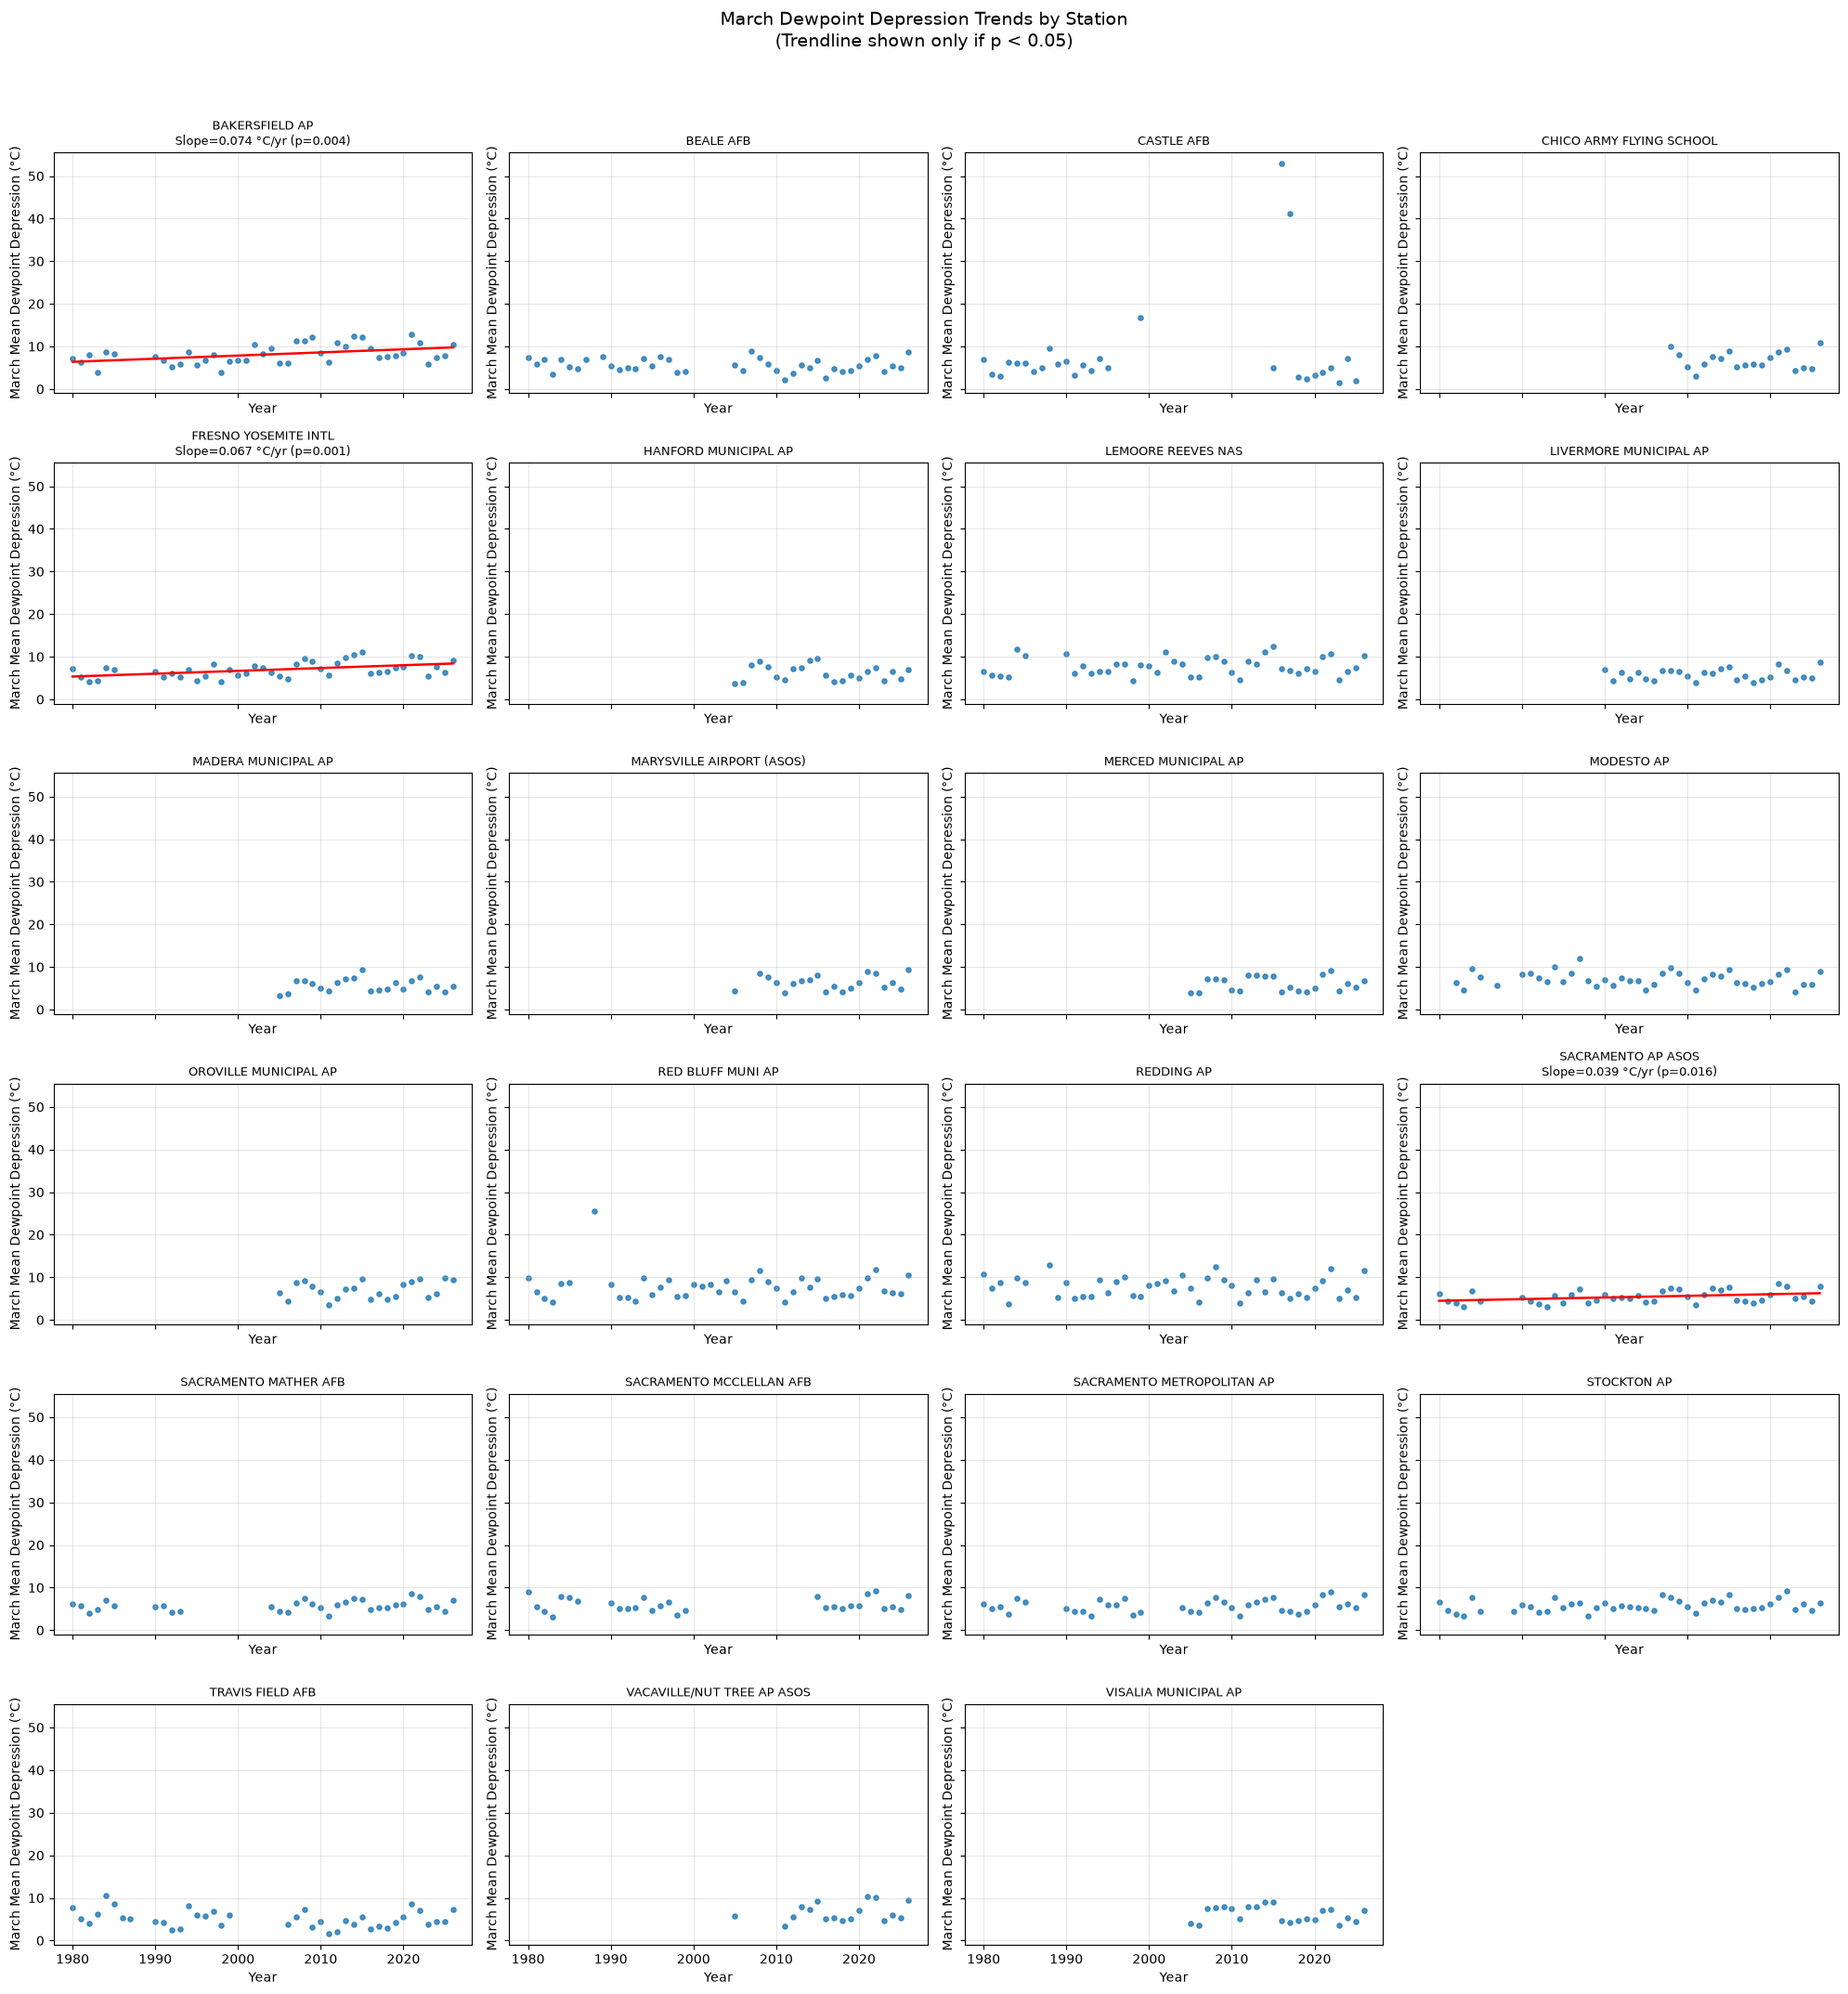

In [21]:
# Scatter plots: only significant stations get trendlines
n_mar_stations = len(march_station_1980["STATION"].unique())
march_stations = sorted(march_station_1980["STATION"].unique())
ncols = 4
nrows = int(np.ceil(n_mar_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

sig_lookup = march_trends_1980.set_index("STATION")["significant"].to_dict()

for idx, station_name in enumerate(march_stations):
    ax = axes[idx]
    g = march_station_1980[march_station_1980["STATION"] == station_name].sort_values("year")

    ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

    # Draw trendline only if significant
    if g["year"].nunique() >= 2 and sig_lookup.get(station_name, False):
        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        y = fit.intercept + fit.slope * x
        ax.plot(x, y, color="red", linewidth=1.8)
        ax.set_title(f"{station_name}\nSlope={fit.slope:.3f} °C/yr (p={fit.pvalue:.3f})", fontsize=9)
    else:
        ax.set_title(station_name, fontsize=9)

    ax.set_xlabel("Year")
    ax.set_ylabel("March Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for idx in range(n_mar_stations, len(axes)):
    axes[idx].axis("off")

fig.suptitle("March Dewpoint Depression Trends by Station\n(Trendline shown only if p < 0.05)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
# April data since 1980
april_station_1980 = (
    monthly_station[
        (monthly_station["month"] == 4) &
        (monthly_station["year"] >= 1980)
    ]
    .dropna(subset=["HourlyDewpointDepression"])
    .copy()
)

# Keep only stations with >10 unique years of April data
station_year_counts = april_station_1980.groupby("STATION")["year"].nunique()
eligible_stations = station_year_counts[station_year_counts > 10].index

april_station_1980 = april_station_1980[
    april_station_1980["STATION"].isin(eligible_stations)
]

# Trend per station (slope in °C per year)
april_trend_rows_1980 = []
for station_name, g in april_station_1980.groupby("STATION"):
    g = g.sort_values("year")
    n_years = g["year"].nunique()
    if n_years <= 10:
        continue  # Skip stations with <= 10 years of data

    fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
    april_trend_rows_1980.append({
        "STATION": station_name,
        "n_years": n_years,
        "start_year": g["year"].min(),
        "end_year": g["year"].max(),
        "slope_per_year": fit.slope,
        "p_value": fit.pvalue,
        "r_value": fit.rvalue,
        "significant": fit.pvalue < alpha
    })

april_trends_1980 = pd.DataFrame(april_trend_rows_1980).sort_values("slope_per_year")
print(april_trends_1980)

print("\nStations included:", len(eligible_stations))
print("Significant trends (p < 0.05):")
print(april_trends_1980[april_trends_1980["significant"]])

                       STATION  n_years  start_year  end_year  slope_per_year  \
11                  MODESTO AP       42        1981      2026       -0.050565   
20            TRAVIS FIELD AFB       38        1980      2026       -0.036485   
22        VISALIA MUNICIPAL AP       22        2005      2026       -0.027419   
1                    BEALE AFB       41        1980      2026       -0.025889   
21  VACAVILLE/NUT TREE AP ASOS       17        2005      2026       -0.016821   
14                  REDDING AP       45        1980      2026       -0.012766   
19                 STOCKTON AP       43        1980      2026        0.001461   
6           LEMOORE REEVES NAS       43        1980      2026        0.003847   
5         HANFORD MUNICIPAL AP       22        2005      2026        0.004893   
17    SACRAMENTO MCCLELLAN AFB       29        1980      2026        0.005333   
8          MADERA MUNICIPAL AP       22        2005      2026        0.008490   
18  SACRAMENTO METROPOLITAN 

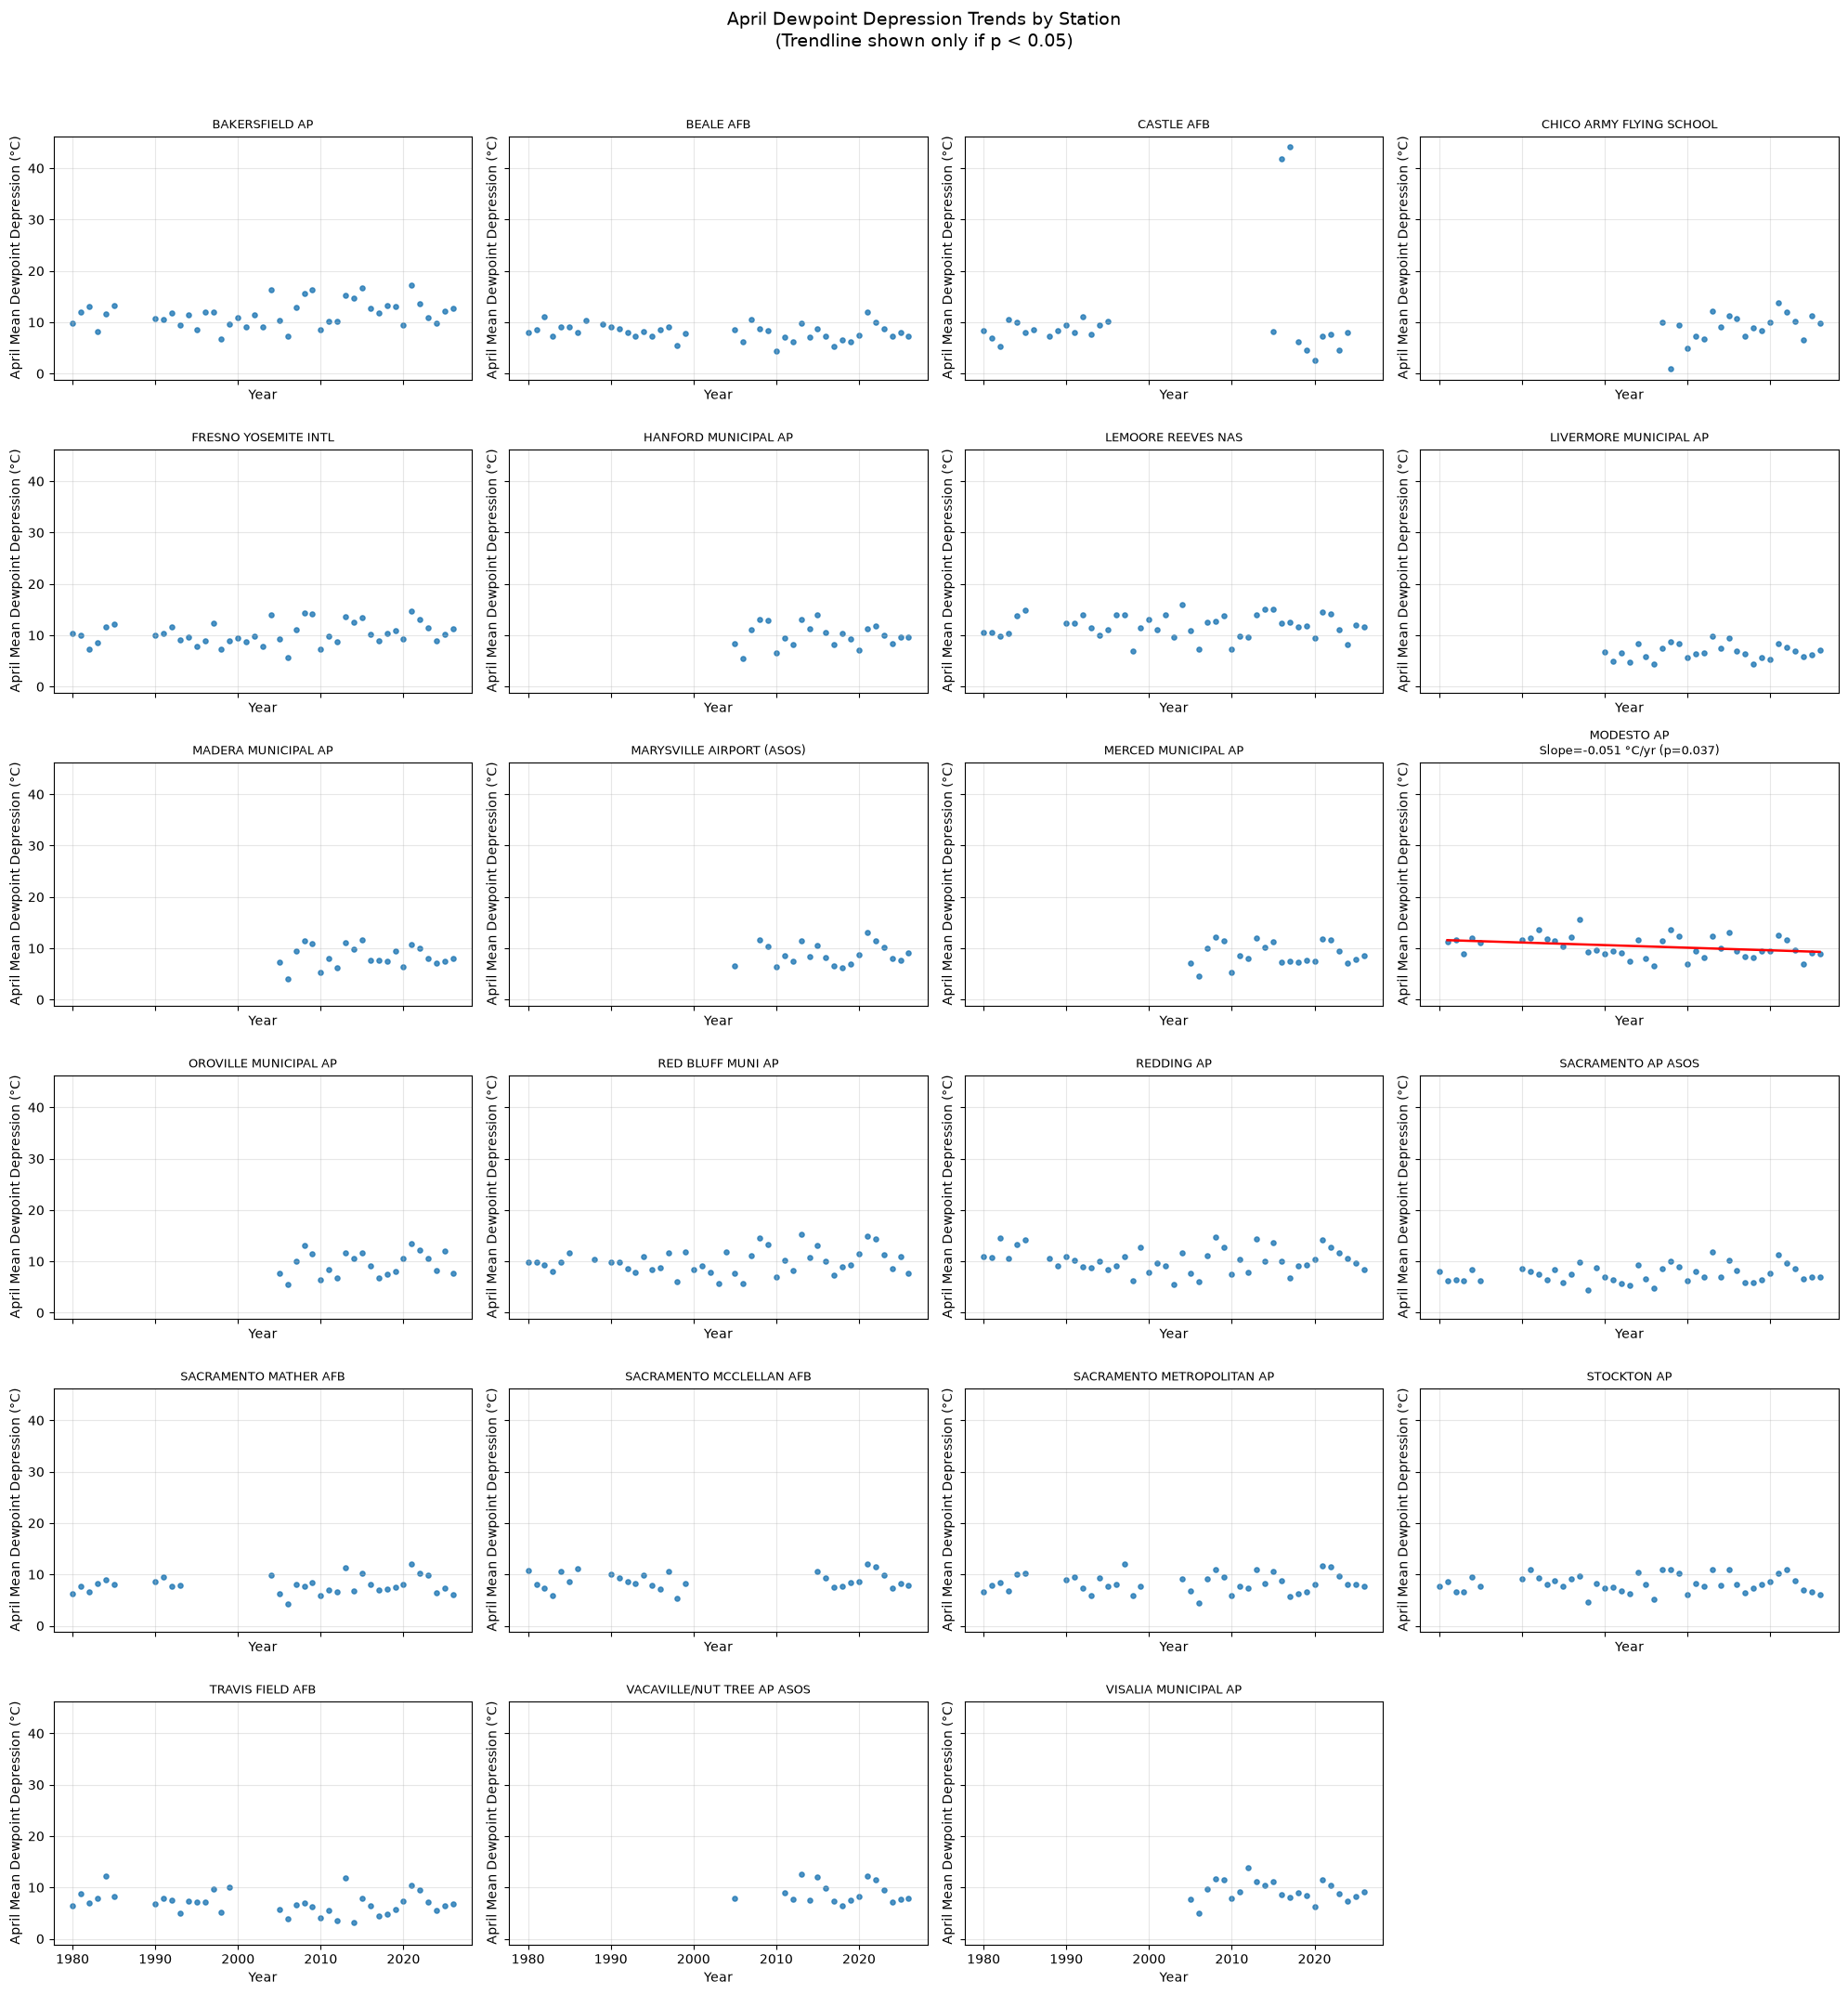

In [23]:
# Scatter plots: only significant stations get trendlines
n_apr_stations = len(april_station_1980["STATION"].unique())
ncols = 4
nrows = int(np.ceil(n_apr_stations / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 3.5 * nrows),
    sharex=True,
    sharey=True
)
axes = np.array(axes).reshape(-1)

sig_lookup = april_trends_1980.set_index("STATION")["significant"].to_dict()

for idx, station_name in enumerate(april_station_1980["STATION"].unique()):
    ax = axes[idx]
    g = april_station_1980[april_station_1980["STATION"] == station_name].sort_values("year")

    ax.scatter(g["year"], g["HourlyDewpointDepression"], s=14, alpha=0.8)

    # Draw trendline only if significant
    if g["year"].nunique() >= 2 and sig_lookup.get(station_name, False):
        fit = stats.linregress(g["year"], g["HourlyDewpointDepression"])
        x = np.array([g["year"].min(), g["year"].max()])
        y = fit.intercept + fit.slope * x
        ax.plot(x, y, color="red", linewidth=1.8)
        ax.set_title(f"{station_name}\nSlope={fit.slope:.3f} °C/yr (p={fit.pvalue:.3f})", fontsize=9)
    else:
        ax.set_title(station_name, fontsize=9)

    ax.set_xlabel("Year")
    ax.set_ylabel("April Mean Dewpoint Depression (°C)")
    ax.grid(alpha=0.3)

for idx in range(n_apr_stations, len(axes)):
    axes[idx].axis("off")

fig.suptitle("April Dewpoint Depression Trends by Station\n(Trendline shown only if p < 0.05)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# filtering based on precipiation to identify fog conditions
# filtering visibility threshold to identify outliers
CV_fog_rows = CV_rows[
    (CV_rows["HourlyPrecipitation"] < 0.03)
    & (CV_rows["HourlyVisibility"] < 17.000)
]

print("CV_fog_rows:", CV_fog_rows.shape) 

CV_fog_rows: (10429072, 17)


In [5]:
# Exclude days from April through October (months 4-10) in CV_fog_rows
CV_fog_rows = CV_fog_rows[~CV_fog_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_fog_rows after removing April-October:", CV_fog_rows.shape)

CV_fog_rows after removing April-October: (4526168, 17)


In [6]:
print(CV_fog_rows["HourlyVisibility"].max())


16.093
